# Chapter 1 - Giving Computers the Ability to Learn from Data

## Core question

How can we translate a real problem into a machine-learning task, represent its data precisely, and design a workflow whose final evaluation still means what we claim it means?

Chapter 1 provides the vocabulary, visual models, and mathematical notation used throughout the course. It does not ask you to master a particular learning algorithm. Chapter 2 will use this foundation to derive and implement the perceptron and Adaline classifiers.

A fixed rule is sufficient when the relevant conditions and responses can already be specified reliably. Machine learning becomes useful when examples contain a relationship that is difficult to write as a complete set of rules. It does not remove the need to define the observation, available information, intended output, and consequences of error.

### How to read this chapter

- The direct foundation for Chapter 2 is supervised binary classification, feature and target notation, the linear score, weights, bias, prediction error, and loss.
- The distinctions among other learning signals, data boundaries, train-fitted transformations, and evaluation evidence are foundations for the complete course and for your individual project.
- Mathematical derivations explain where important calculations come from. Follow the symbols and numerical checks even if you do not memorize every equation on the first reading.
- Reinforcement-learning return, K-means, Isomap, and general test loss are previews of later topics. Understand the question and the evidence boundary; their full algorithms are not Chapter 1 learning requirements.
- Some executable cells contain drawing instructions so that the figures can be reproduced. Run those cells and interpret their outputs; you are not expected to memorize the Matplotlib drawing code.

### Learning outcomes

After completing this chapter, you should be able to:

1. distinguish supervised, unsupervised, and reinforcement learning from the information available during learning;
2. distinguish classification from regression by the type of target being predicted;
3. represent observations, features, and targets with the matrix notation used in the textbook;
4. explain clustering and dimensionality reduction without pretending that unknown labels are known;
5. trace the boundary between training, model selection, final testing, and prediction on new data;
6. identify a concrete route by which preprocessing can leak test information; and
7. preserve enough version, data, and evaluation evidence for another person to inspect a result.

Run the notebook from top to bottom in a fresh kernel. Every figure is generated from course-written code; no publisher figure is embedded or traced.

## Notebook setup

The code uses only bundled or course-standard libraries and does not download data. The Iris dataset is loaded from scikit-learn. Every other dataset is explicitly labeled as synthetic or artificial teaching data. Most of the setup cell defines display helpers for tables and diagrams. Run the cell, but focus your study on the later data calculations rather than these display details.

In [1]:
# Run this setup cell before the demonstrations below.
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn

from IPython.display import display
from matplotlib.patches import Ellipse, FancyArrowPatch, FancyBboxPatch

CLASSIFICATION_SEED = 7
STRUCTURE_SEED = 11
SPLIT_SEED = 17
DARK = "#17324D"
ACCENT = "#2A7F62"
SECONDARY = "#C76B16"
LIGHT = "#EAF1F4"
WARM = "#F7E8CF"
MUTED = "#667085"
DANGER = "#B42318"

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 20)
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.20,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

_table_number = 0


def show_table(frame, caption, formats=None):
    # Display a compact table with a deterministic HTML identifier.
    global _table_number
    _table_number += 1
    styled = (
        frame.style.hide(axis="index")
        .set_caption(caption)
        .set_uuid(f"ch01_{_table_number:02d}")
        .set_table_styles(
            [
                {"selector": "caption", "props": "caption-side: top; text-align: left; font-weight: bold; color: #17324D;"},
                {"selector": "th", "props": "background-color: #EAF1F4; text-align: left;"},
                {"selector": "td", "props": "text-align: left; vertical-align: top;"},
            ]
        )
    )
    if formats:
        styled = styled.format(formats, na_rep="-")
    display(styled)


def draw_box(ax, x, y, width, height, text, facecolor=LIGHT, linestyle="-", fontsize=11):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.06",
        linewidth=1.5,
        edgecolor=DARK,
        facecolor=facecolor,
        linestyle=linestyle,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize)
    return box


def draw_arrow(ax, start, end, label=None, color=DARK, linestyle="-", label_offset=0.18):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.5,
        color=color,
        linestyle=linestyle,
    )
    ax.add_patch(arrow)
    if label:
        ax.text(
            (start[0] + end[0]) / 2,
            (start[1] + end[1]) / 2 + label_offset,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            color=color,
        )
    return arrow


print(
    "Purpose-specific random seeds:",
    {
        "classification example": CLASSIFICATION_SEED,
        "clustering and Swiss roll": STRUCTURE_SEED,
        "data splits": SPLIT_SEED,
    },
)

Purpose-specific random seeds: {'classification example': 7, 'clustering and Swiss roll': 11, 'data splits': 17}


## Issue 1 - What information does the learner receive?

Calling a system "machine learning" does not yet identify what it learns from. The first useful distinction is the signal available during learning.

> **Before running the next cell:** Predict which learning type receives known targets, which receives inputs without known targets, and which learns through actions and rewards. For each row, name the output the learner is expected to produce.

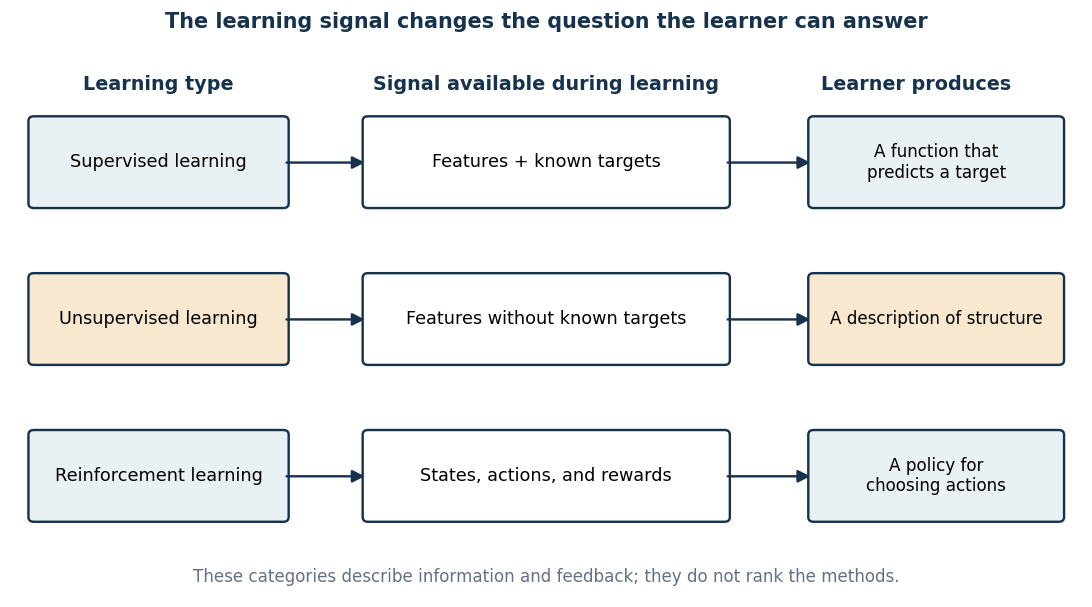

In [2]:
# Course-added overview of three learning types.
fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

ax.text(1.65, 6.45, "Learning type", ha="center", weight="bold", color=DARK, fontsize=12)
ax.text(6.0, 6.45, "Signal available during learning", ha="center", weight="bold", color=DARK, fontsize=12)
ax.text(10.15, 6.45, "Learner produces", ha="center", weight="bold", color=DARK, fontsize=12)

rows = [
    (5.0, "Supervised learning", "Features + known targets", "A function that\npredicts a target"),
    (3.0, "Unsupervised learning", "Features without known targets", "A description of structure"),
    (1.0, "Reinforcement learning", "States, actions, and rewards", "A policy for\nchoosing actions"),
]
for row_number, (y_position, learning_type, signal, result) in enumerate(rows):
    fill = LIGHT if row_number != 1 else WARM
    draw_box(ax, 0.25, y_position, 2.8, 1.05, learning_type, facecolor=fill, fontsize=11)
    draw_box(ax, 4.0, y_position, 4.0, 1.05, signal, facecolor="white", fontsize=11)
    draw_box(ax, 9.0, y_position, 2.75, 1.05, result, facecolor=fill, fontsize=10.5)
    draw_arrow(ax, (3.05, y_position + 0.52), (4.0, y_position + 0.52))
    draw_arrow(ax, (8.0, y_position + 0.52), (9.0, y_position + 0.52))

ax.set_title("The learning signal changes the question the learner can answer", weight="bold", color=DARK, pad=12)
ax.text(
    6.0, 0.18,
    "These categories describe information and feedback; they do not rank the methods.",
    ha="center", color=MUTED, fontsize=10.5,
)
plt.show()

The three rows differ before an algorithm is chosen. Supervised learning receives known targets during fitting. Unsupervised learning does not. Reinforcement learning receives consequences of actions through interaction rather than a table containing the correct action for every state.

**Information available to each type of learning**

| Learning type | Learning signal | Learner produces | The signal does not guarantee |
|---|---|---|---|
| Supervised learning | Inputs paired with known targets | Predictions for new inputs | Future data match the training data |
| Unsupervised learning | Inputs without known targets | Groups or representations | A correct external meaning for each pattern |
| Reinforcement learning | States, actions, and rewards from interaction | A policy for choosing actions | A correct-action label for every state |

A spam classifier trained from messages already labeled "spam" or "not spam" is supervised. A procedure that groups messages without those labels is unsupervised. An agent that chooses filtering actions and receives delayed rewards is a reinforcement-learning formulation only if actions, interaction, and reward are genuinely part of the problem.

### Textbook terminology used throughout the course

The textbook notes that machine-learning sources often use several words for the same role. In the tabular representation used here, each **training example** occupies one row and may also be called an observation, record, instance, or data point. The textbook warns that *sample* often refers to a collection of training examples, so check the surrounding definition. **Training** is also called model fitting. A **feature** may be called a predictor, input, attribute, variable, or covariate. A **target** may be called an outcome, output, response variable, dependent variable, class label, or ground truth.

A loss function measures disagreement between a target and a prediction. Some sources use *loss* and *cost* as synonyms; others use loss for one observation and cost for a sum or average over several observations. This notebook defines the exact calculation whenever either word is needed.

### A precise supervised-learning statement

Let one observation have $m$ numerically represented features. Raw text, images, or categories require an explicit representation before the following vector notation applies. A supervised learner uses pairs

$$
(\mathbf{x}^{(i)},y^{(i)}),\qquad i=1,\ldots,n,
$$

where $\mathbf{x}^{(i)}$ contains the features of observation $i$ and $y^{(i)}$ is its known target during training. Throughout this notebook, an observation stored as one row of $\mathbf{X}$ is treated as a row vector. Learning produces a function $f$ that maps a new feature vector to a prediction:

$$
\hat y=f(\mathbf{x}).
$$

The hat in $\hat y$ matters: $\hat y$ is a model output, while $y$ is an observed target used for checking it. The function notation is a course-added mathematical formulation of the textbook's verbal description.

> **Before running the next cell:** Predict which two inputs are available during fitting and which input is unavailable when a new prediction is produced. Also predict whether the learning algorithm or the fitted model is applied to the new observation.

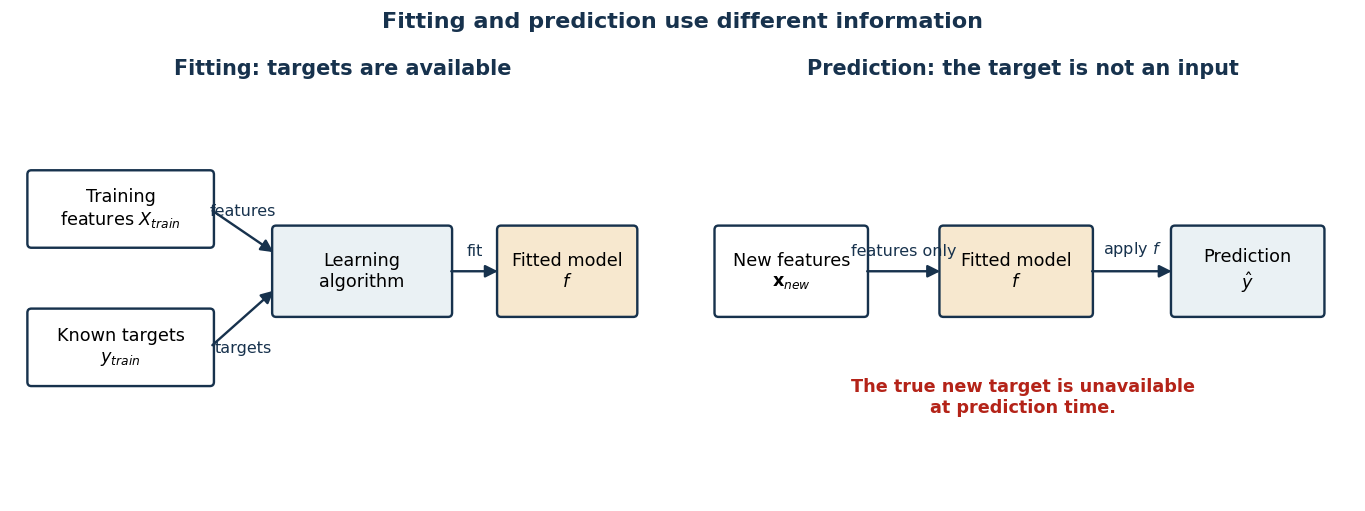

Phase,Features,Known target,Object used,Output
Fit the model,training feature matrix,training target vector,Learning algorithm,Fitted model
Produce a prediction,new feature vector,unavailable at prediction time,Fitted model f,Predicted target


In [3]:
# Course-added supervised-learning process.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

draw_box(axes[0], 0.3, 3.7, 2.7, 1.0, "Training\nfeatures $X_{train}$", facecolor="white")
draw_box(axes[0], 0.3, 1.7, 2.7, 1.0, "Known targets\n$y_{train}$", facecolor="white")
draw_box(axes[0], 4.0, 2.7, 2.6, 1.2, "Learning\nalgorithm", facecolor=LIGHT)
draw_box(axes[0], 7.4, 2.7, 2.0, 1.2, "Fitted model\n$f$", facecolor=WARM)
draw_arrow(axes[0], (3.0, 4.2), (4.0, 3.55), "features")
draw_arrow(axes[0], (3.0, 2.2), (4.0, 3.05), "targets", label_offset=-0.55)
draw_arrow(axes[0], (6.6, 3.3), (7.4, 3.3), "fit")
axes[0].set_title("Fitting: targets are available", weight="bold", color=DARK)

draw_box(axes[1], 0.4, 2.7, 2.2, 1.2, "New features\n$\\mathbf{x}_{new}$", facecolor="white")
draw_box(axes[1], 3.8, 2.7, 2.2, 1.2, "Fitted model\n$f$", facecolor=WARM)
draw_box(axes[1], 7.3, 2.7, 2.2, 1.2, "Prediction\n$\\hat y$", facecolor=LIGHT)
draw_arrow(axes[1], (2.6, 3.3), (3.8, 3.3), "features only")
draw_arrow(axes[1], (6.0, 3.3), (7.3, 3.3), "apply $f$")
axes[1].text(5.0, 1.25, "The true new target is unavailable\nat prediction time.", ha="center", color=DANGER, weight="bold")
axes[1].set_title("Prediction: the target is not an input", weight="bold", color=DARK)

fig.suptitle("Fitting and prediction use different information", fontsize=14, weight="bold", color=DARK)
fig.tight_layout()
plt.show()

phase_table = pd.DataFrame(
    {
        "Phase": ["Fit the model", "Produce a prediction"],
        "Features": ["training feature matrix", "new feature vector"],
        "Known target": ["training target vector", "unavailable at prediction time"],
        "Object used": ["Learning algorithm", "Fitted model f"],
        "Output": ["Fitted model", "Predicted target"],
    }
)
show_table(phase_table, "Information used during fitting and prediction")

The left panel and table show that fitting uses both $\mathbf{X}_{train}$ and $\mathbf{y}_{train}$. The right panel shows that a new prediction uses $\mathbf{x}_{new}$ while its target is unavailable at prediction time. The learning algorithm estimates the fitted model $f$; the fitted model, not a new fitting operation, is then applied to the new observation. Issue 5 later defines development data as the training and validation evidence used while a procedure is being developed. The present diagram describes fitting one model, not that larger model-selection process.

**Reasoning check.** A retailer has transaction records but no agreed definition of customer segments. Is clustering automatically useful? State what external evidence would be needed before attaching business meaning to the groups.

## Issue 2 - Does the target name a category or measure a quantity?

Supervised learning contains two central task types. The equations below are course-added formulations that make the textbook's verbal descriptions explicit.

### Classification

For $K$ possible class labels, a classifier maps a feature vector to one label:

$$
f:\mathbb{R}^{m}\rightarrow\{c_1,c_2,\ldots,c_K\}.
$$

The labels are categories, not numerical distances. If Setosa, Versicolor, and Virginica are encoded as 0, 1, and 2, the code does not make Virginica twice Versicolor. Binary classification has two possible classes; multiclass classification has more than two.

The synthetic rule below can also be written with the row-vector convention used in this notebook:

$$
s^{(i)}=\mathbf{x}^{(i)}\mathbf{w}+b,
\qquad
\mathbf{w}=\begin{bmatrix}1\\1\end{bmatrix},
\qquad b=0.
$$

Here, $\mathbf{x}^{(i)}\in\mathbb{R}^{1\times2}$, $\mathbf{w}\in\mathbb{R}^{2\times1}$, and the product $s^{(i)}\in\mathbb{R}$ is one scalar score. The declared rule assigns Class B when $s^{(i)}>0$. These weights are specified for the illustration; Chapter 2 asks how a learning algorithm can estimate weights from errors.

> **Before running the next cell:** The illustrative decision rule assigns Class B when $x_1+x_2>0$. Predict the class assigned to the marked point $(0.55,0.20)$, and identify the calculation that supports your answer.

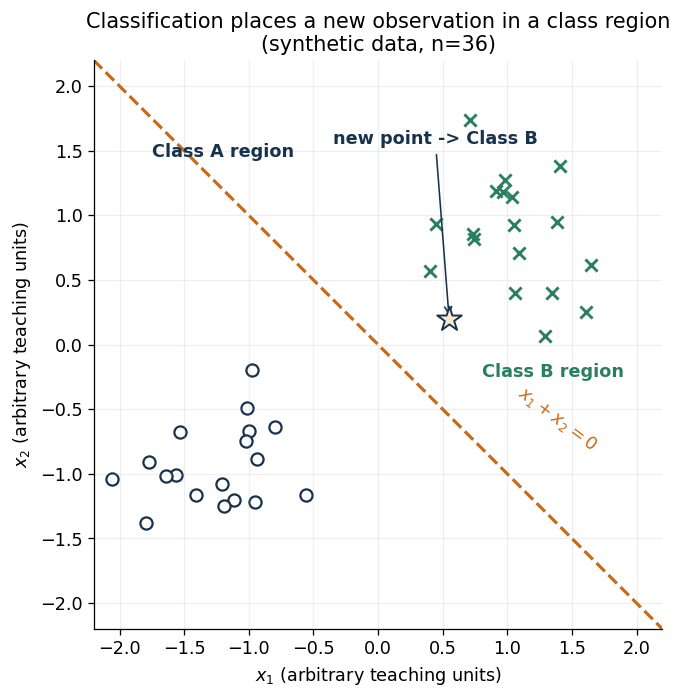

x1 (teaching units),x2 (teaching units),score x1 + x2 (teaching units),predicted class
0.55,0.20,0.75,B


In [4]:
# Course-added synthetic classification example.
rng = np.random.default_rng(CLASSIFICATION_SEED)
class_a = rng.normal(loc=(-1.0, -0.8), scale=(0.42, 0.45), size=(18, 2))
class_b = rng.normal(loc=(1.0, 0.9), scale=(0.45, 0.42), size=(18, 2))
new_point = np.array([0.55, 0.20])
new_score = new_point.sum()
new_class = "B" if new_score > 0 else "A"

fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.scatter(class_a[:, 0], class_a[:, 1], marker="o", s=58, facecolors="white", edgecolors=DARK, linewidths=1.4)
ax.scatter(class_b[:, 0], class_b[:, 1], marker="x", s=58, color=ACCENT, linewidths=1.8)
boundary_x = np.linspace(-2.2, 2.2, 100)
ax.plot(boundary_x, -boundary_x, linestyle="--", color=SECONDARY, linewidth=2.0)
ax.scatter(*new_point, marker="*", s=260, color=WARM, edgecolor=DARK, linewidth=1.2, zorder=5)

ax.text(-1.75, 1.45, "Class A region", color=DARK, weight="bold")
ax.text(1.35, -0.25, "Class B region", color=ACCENT, weight="bold", ha="center")
ax.annotate(
    f"new point -> Class {new_class}",
    xy=new_point,
    xytext=(-0.35, 1.55),
    arrowprops={"arrowstyle": "->", "color": DARK},
    color=DARK,
    weight="bold",
)
ax.text(1.05, -0.82, "$x_1+x_2=0$", color=SECONDARY, rotation=-37, weight="bold")
ax.set(
    xlabel="$x_1$ (arbitrary teaching units)",
    ylabel="$x_2$ (arbitrary teaching units)",
    title="Classification places a new observation in a class region\n(synthetic data, n=36)",
    xlim=(-2.2, 2.2),
    ylim=(-2.2, 2.2),
)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

classification_result = pd.DataFrame(
    {
        "x1 (teaching units)": [new_point[0]],
        "x2 (teaching units)": [new_point[1]],
        "score x1 + x2 (teaching units)": [new_score],
        "predicted class": [new_class],
    }
)
show_table(
    classification_result,
    "Prediction for the marked synthetic observation; Class B is assigned when x1 + x2 > 0",
    {"x1 (teaching units)": "{:.2f}", "x2 (teaching units)": "{:.2f}", "score x1 + x2 (teaching units)": "{:.2f}"},
)

For the marked point, $\mathbf{x}=[0.55\;0.20]$, so $s=\mathbf{x}\mathbf{w}+b=0.55+0.20=0.75$. The declared rule therefore assigns it to Class B. The score has the arbitrary teaching unit shared by $x_1$ and $x_2$ in this constructed example. The boundary and both groups are synthetic teaching data. They show how a categorical decision can divide feature space; they do not show that this boundary would be suitable for a real application.

### Regression

A regression model predicts a continuous quantity:

$$
f:\mathbb{R}^{m}\rightarrow\mathbb{R}.
$$

A linear prediction for row-vector observation $i$ can be written as

$$
\hat y^{(i)}=\mathbf{x}^{(i)}\mathbf{w}+b
=\sum_{j=1}^{m}x_j^{(i)}w_j+b,
\qquad
\mathbf{w}\in\mathbb{R}^{m\times1}.
$$

The multiplication is dimensionally valid because $(1\times m)(m\times1)$ produces one scalar. Here, $\mathbf{w}$ contains one fitted weight per feature and $b$ is the intercept. For observation $i$, the residual is

$$
e^{(i)}=y^{(i)}-\hat y^{(i)}.
$$

The chapter describes fitting a line by minimizing average squared distance. Written as mean squared error (MSE), that idea is

$$
\operatorname{MSE}=\frac{1}{n}\sum_{i=1}^{n}\left(y^{(i)}-\hat y^{(i)}\right)^2.
$$

This formulation uses vertical residuals and requires $n>0$. Squaring prevents positive and negative residuals from canceling and gives large residuals greater influence. MSE has squared target units. In the linear equation, $b$ has target units, while $w_j$ has target units per unit of feature $j$. The equation assumes an additive linear form; it does not establish causation.

#### Optional mathematical derivation: the simple least-squares line

This derivation explains the one-feature calculation in full, but it is not a prerequisite for the perceptron in Chapter 2. For the line $\hat y^{(i)}=b+wx^{(i)}$, define the sum of squared errors

$$
S(w,b)=\sum_{i=1}^{n}\left(y^{(i)}-b-wx^{(i)}\right)^2.
$$

Because $S(w,b)=n\,\operatorname{MSE}(w,b)$ and $n$ is a positive constant, the values of $w$ and $b$ that minimize $S$ also minimize MSE.

At an interior minimum, the partial derivatives with respect to $b$ and $w$ are zero. The first condition is

$$
\frac{\partial S}{\partial b}
=-2\sum_{i=1}^{n}\left(y^{(i)}-b-wx^{(i)}\right)=0.
$$

Rearranging gives $nb=\sum_i y^{(i)}-w\sum_i x^{(i)}$, or $b=\bar y-w\bar x$, where

$$
\bar x=\frac{1}{n}\sum_{i=1}^{n}x^{(i)},
\qquad
\bar y=\frac{1}{n}\sum_{i=1}^{n}y^{(i)}.
$$

The second condition is

$$
\frac{\partial S}{\partial w}
=-2\sum_{i=1}^{n}x^{(i)}
\left(y^{(i)}-b-wx^{(i)}\right)=0.
$$

Substituting $b=\bar y-w\bar x$ and collecting centered terms gives

$$
\sum_{i=1}^{n}(x^{(i)}-\bar x)(y^{(i)}-\bar y)
-w\sum_{i=1}^{n}(x^{(i)}-\bar x)^2=0.
$$

Therefore,

$$
w=
\frac{\sum_{i=1}^{n}(x^{(i)}-\bar x)(y^{(i)}-\bar y)}
{\sum_{i=1}^{n}(x^{(i)}-\bar x)^2},
\qquad
b=\bar y-w\bar x.
$$

The denominator must be positive, so the observed $x$ values cannot all be equal. Under this condition, $S(w,b)$ is a convex quadratic with a unique stationary point, so the calculated stationary point is the unique global minimum. These equations are a course-added derivation of the fitted line described verbally in the textbook. The next cell implements the displayed calculations directly with NumPy.

> **Before running the next cell:** Predict whether the largest absolute residual must occur at the largest $x$ value. In the figure, identify what the vertical line segment between an observation and the fitted line represents.

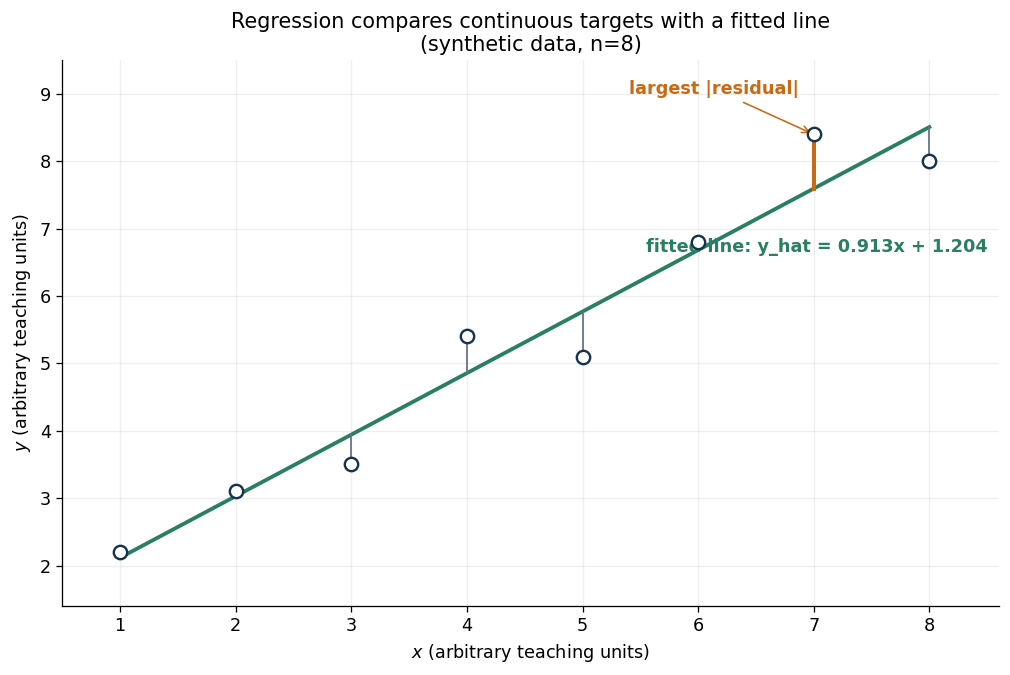

Quantity,Value,Unit,Interpretation
Mean x,4.5000,x units,average observed x
Mean y,5.3125,target units,average observed target
Slope numerator,38.3500,x units times target units,centered x-y cross-product sum
Slope denominator,42.0000,x units squared,centered x squared sum
Slope w,0.9131,target units per x unit,numerator divided by denominator
Intercept b,1.2036,target units,fitted value at x = 0 (outside the observed x range)
MSE,0.2339,target units squared,average squared residual
Largest |residual|,0.8048,target units,occurs at x = 7.0


In [5]:
# Course-added synthetic regression example.
x_reg = np.arange(1.0, 9.0)
y_reg = np.array([2.2, 3.1, 3.5, 5.4, 5.1, 6.8, 8.4, 8.0])
if np.all(x_reg == x_reg[0]):
    raise ValueError("A unique line slope cannot be fitted when all x values are equal.")
x_bar = x_reg.mean()
y_bar = y_reg.mean()
centered_x = x_reg - x_bar
centered_y = y_reg - y_bar
slope_numerator = np.sum(centered_x * centered_y)
slope_denominator = np.sum(centered_x**2)
if not np.isfinite(slope_denominator) or slope_denominator <= 0.0:
    raise ValueError("The squared x spread cannot be represented reliably; rescale x before fitting.")
w = slope_numerator / slope_denominator
b = y_bar - w * x_bar
y_hat = b + w * x_reg
residual = y_reg - y_hat
mse = np.mean(residual**2)
largest_index = int(np.argmax(np.abs(residual)))

fig, ax = plt.subplots(figsize=(9.2, 6.0))
ax.scatter(x_reg, y_reg, marker="o", s=70, facecolors="white", edgecolors=DARK, linewidths=1.5, zorder=4)
ax.plot(x_reg, y_hat, color=ACCENT, linewidth=2.4)
for index, (x_value, observed, predicted) in enumerate(zip(x_reg, y_reg, y_hat)):
    line_color = SECONDARY if index == largest_index else MUTED
    line_width = 2.5 if index == largest_index else 1.1
    ax.plot([x_value, x_value], [predicted, observed], color=line_color, linewidth=line_width)

ax.text(5.55, b + w * 5.55 + 0.38, f"fitted line: y_hat = {w:.3f}x + {b:.3f}", color=ACCENT, weight="bold")
ax.annotate(
    "largest |residual|",
    xy=(x_reg[largest_index], y_reg[largest_index]),
    xytext=(5.4, 9.0),
    arrowprops={"arrowstyle": "->", "color": SECONDARY},
    color=SECONDARY,
    weight="bold",
)
ax.set(
    xlabel="$x$ (arbitrary teaching units)",
    ylabel="$y$ (arbitrary teaching units)",
    title="Regression compares continuous targets with a fitted line\n(synthetic data, n=8)",
    xlim=(0.5, 8.6),
    ylim=(1.4, 9.5),
)
plt.tight_layout()
plt.show()

regression_result = pd.DataFrame(
    {
        "Quantity": ["Mean x", "Mean y", "Slope numerator", "Slope denominator", "Slope w", "Intercept b", "MSE", "Largest |residual|"],
        "Value": [x_bar, y_bar, slope_numerator, slope_denominator, w, b, mse, abs(residual[largest_index])],
        "Unit": [
            "x units",
            "target units",
            "x units times target units",
            "x units squared",
            "target units per x unit",
            "target units",
            "target units squared",
            "target units",
        ],
        "Interpretation": [
            "average observed x",
            "average observed target",
            "centered x-y cross-product sum",
            "centered x squared sum",
            "numerator divided by denominator",
            "fitted value at x = 0 (outside the observed x range)",
            "average squared residual",
            f"occurs at x = {x_reg[largest_index]:.1f}",
        ],
    }
)
show_table(
    regression_result,
    "Fitted regression quantities for eight synthetic observations",
    {"Value": "{:.4f}"},
)

The output gives $\bar x=4.5000$ and $\bar y=5.3125$. The centered cross-product sum is 38.3500 and the centered squared-$x$ sum is 42.0000, so $w=38.3500/42.0000=0.9131$. Then $b=5.3125-(0.913095)(4.5)=1.2036$. The resulting MSE is 0.2339. The highlighted largest absolute residual is 0.8048 target units and occurs at $x=7.0$, not at the largest $x$ value. Each vertical segment is an observed residual $y^{(i)}-\hat y^{(i)}$. A positive fitted slope does not establish that $x$ causes $y$ to increase.

**Reasoning check.** If a university encodes first year, second year, third year, and fourth year as 1-4, does that automatically make the task regression? Identify the target being predicted before deciding.

## Issue 3 - How do reinforcement learning and unsupervised learning differ from supervised learning?

The learning signals in this issue are part of the Chapter 1 foundation. The return calculation, K-means objective, and Isomap computation are previews: use them to understand what the outputs mean, not to claim mastery of the algorithms.

### Reinforcement learning

An agent observes a state $s_t$, chooses an action $a_t$, and receives a reward $r_{t+1}$ as the environment changes. The action goes from the agent to the environment. The next state and reward return from the environment to the agent.

> **Reading check before viewing the diagram:** Which quantity is chosen by the agent, and which two quantities return after the environment responds? Explain why a table of correct action labels for every state would describe a different learning signal.

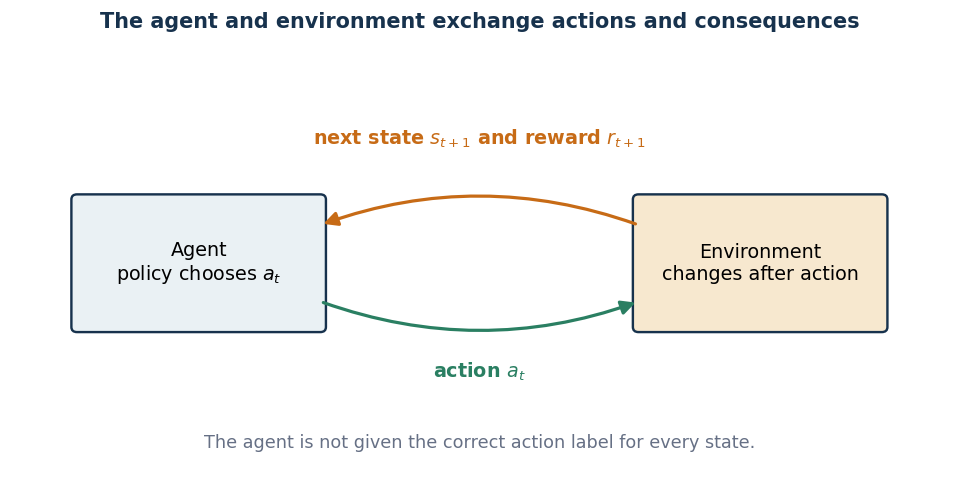

In [6]:
# Course-added reinforcement-learning interaction.
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

draw_box(ax, 0.7, 1.7, 2.6, 1.5, "Agent\npolicy chooses $a_t$", facecolor=LIGHT, fontsize=12)
draw_box(ax, 6.7, 1.7, 2.6, 1.5, "Environment\nchanges after action", facecolor=WARM, fontsize=12)
action_arrow = FancyArrowPatch(
    (3.3, 2.0), (6.7, 2.0), connectionstyle="arc3,rad=0.18", arrowstyle="-|>",
    mutation_scale=18, linewidth=2.0, color=ACCENT,
)
feedback_arrow = FancyArrowPatch(
    (6.7, 2.9), (3.3, 2.9), connectionstyle="arc3,rad=0.18", arrowstyle="-|>",
    mutation_scale=18, linewidth=2.0, color=SECONDARY,
)
ax.add_patch(action_arrow)
ax.add_patch(feedback_arrow)
ax.text(5.0, 1.10, "action $a_t$", ha="center", color=ACCENT, weight="bold", fontsize=12)
ax.text(5.0, 3.85, "next state $s_{t+1}$ and reward $r_{t+1}$", ha="center", color=SECONDARY, weight="bold", fontsize=12)
ax.set_title("The agent and environment exchange actions and consequences", weight="bold", color=DARK, pad=12)
ax.text(5.0, 0.28, "The agent is not given the correct action label for every state.", ha="center", color=MUTED)
plt.show()

The lower arrow carries action $a_t$ from the agent to the environment. The upper arrow carries the next state $s_{t+1}$ and reward $r_{t+1}$ back to the agent. This direction matters: the agent's action can change what it observes next.

#### Mathematical preview: a finite-horizon return

When rewards can be delayed, one common course-added mathematical description of the return from time $t$ is

$$
G_t=r_{t+1}+\gamma r_{t+2}+\gamma^2r_{t+3}+\cdots
=\sum_{k=0}^{T-t-1}\gamma^k r_{t+k+1},
$$

where $T$ is the terminal time, $t<T$, and the dimensionless factor $0\leq\gamma\leq1$ controls how strongly later rewards count. At the terminal time, the empty future sum is defined as $G_T=0$. If every reward uses the same reward scale, $G_t$ has that same unit. This finite-horizon equation makes delayed feedback explicit; it does not imply that every reinforcement-learning method uses the same horizon or return definition.

> **Before running the next cell:** For rewards $[0,-1,5]$ and $\gamma=0.8$, predict the discounted contribution of the reward $5$ received two steps later. Then predict whether $G_t$ is greater or less than the undiscounted sum $4$.

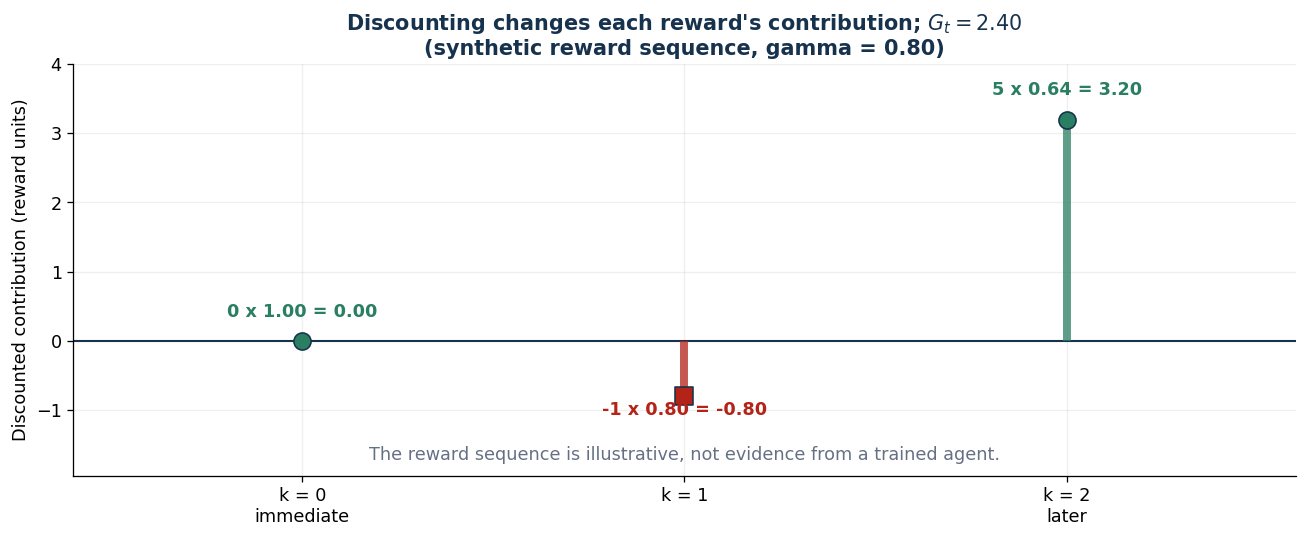

Step k,Reward (reward units),Discount weight,Discounted contribution (reward units)
0,0.0,1.00,0.00
1,-1.0,0.80,-0.80
2,5.0,0.64,3.20


In [7]:
# Course-added discounted-reward timeline.
gamma = 0.8
rewards = np.array([0.0, -1.0, 5.0])
steps = np.arange(len(rewards))
weights = gamma ** steps
contributions = weights * rewards
discounted_return = contributions.sum()

fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-1.95, 4.0)
ax.axhline(0, color=DARK, linewidth=1.3)
for step, reward, weight, contribution in zip(steps, rewards, weights, contributions):
    marker = "o" if contribution >= 0 else "s"
    color = ACCENT if contribution >= 0 else DANGER
    ax.vlines(step, 0, contribution, color=color, linewidth=5, alpha=0.75)
    ax.scatter(step, contribution, marker=marker, s=115, color=color, edgecolor=DARK, zorder=3)
    ax.text(
        step,
        contribution + (0.35 if contribution >= 0 else -0.28),
        f"{reward:g} x {weight:.2f} = {contribution:.2f}",
        ha="center",
        color=color,
        weight="bold",
    )

ax.set_xticks(steps, ["k = 0\nimmediate", "k = 1", "k = 2\nlater"])
ax.set_ylabel("Discounted contribution (reward units)")
ax.set_title(
    f"Discounting changes each reward's contribution; $G_t={discounted_return:.2f}$\n"
    f"(synthetic reward sequence, gamma = {gamma:.2f})",
    weight="bold",
    color=DARK,
)
ax.text(1.0, -1.72, "The reward sequence is illustrative, not evidence from a trained agent.", ha="center", color=MUTED)
plt.tight_layout()
plt.show()

reward_table = pd.DataFrame(
    {
        "Step k": steps,
        "Reward (reward units)": rewards,
        "Discount weight": weights,
        "Discounted contribution (reward units)": contributions,
    }
)
show_table(
    reward_table,
    f"Discounted contributions for a synthetic reward sequence; gamma = {gamma:.2f}, G_t = {discounted_return:.2f}",
    {"Reward (reward units)": "{:.1f}", "Discount weight": "{:.2f}", "Discounted contribution (reward units)": "{:.2f}"},
)

The reward $5$ at $k=2$ receives weight $0.8^2=0.64$ and contributes 3.20. The penalty $-1$ at $k=1$ contributes -0.80, so the displayed return is $0-0.8+3.2=2.4$, less than the undiscounted sum $4$. These numbers verify the formula; they are not results from a trained policy.

### Preview: clustering

Clustering seeks groups whose members are similar under declared features and a declared similarity rule. The textbook introduces this idea conceptually; the following Euclidean-distance equation is a course-added mathematical bridge:

$$
d\!\left(\mathbf{x}^{(a)},\mathbf{x}^{(b)}\right)
=\sqrt{\sum_{j=1}^{m}\left(x_j^{(a)}-x_j^{(b)}\right)^2}.
$$

The formula requires numeric feature representations and does not determine which features should be used or whether they should be scaled. Changing units can change distances and therefore the groups. Cluster identifiers such as 0, 1, and 2 are arbitrary names; they are not known class labels.

The K-means demonstration below seeks assignments $c(i)\in\{0,\ldots,K-1\}$ and centroid row vectors $\boldsymbol{\mu}_k\in\mathbb{R}^{1\times m}$ that reduce the within-cluster sum of squared Euclidean distances. Here, $K$ is the requested number of clusters, and the zero-based IDs match the Python output:

$$
J=\sum_{i=1}^{n}\left\|\mathbf{x}^{(i)}-\boldsymbol{\mu}_{c(i)}\right\|_2^2.
$$

For a nonempty cluster $k$, let $n_k$ be the number of assigned observations. Holding its membership fixed and minimizing squared distance gives the coordinate-wise mean

$$
\boldsymbol{\mu}_k
=\frac{1}{n_k}\sum_{i:c(i)=k}\mathbf{x}^{(i)},
\qquad n_k>0.
$$

These equations are a course-added preview. If all coordinates share one feature unit, $J$ has that unit squared; with unlike feature units, it is a sum of unlike squared numeric coordinates and is sensitive to scaling. The implementation searches for a low value of $J$; the output does not prove that the reported grouping is the only possible solution or has external meaning.

> **Reading check before viewing the output:** Explain why cluster IDs can be permuted without changing the partition. Because both panels use the same 105 observations and axis limits, identify exactly what changes from the left panel to the right panel.

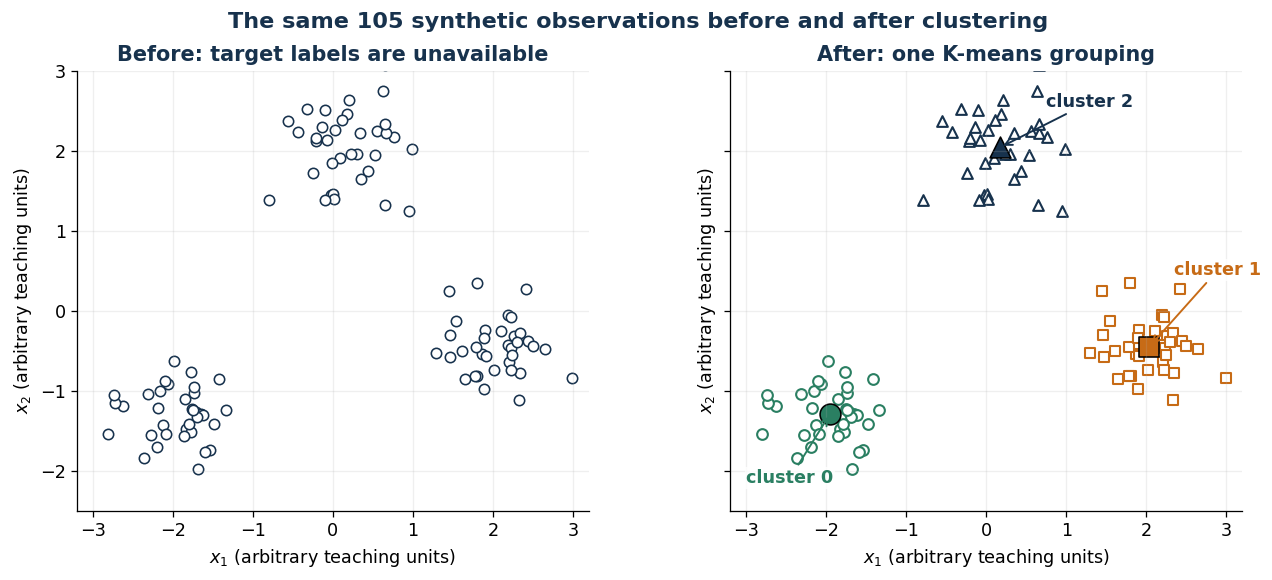

Cluster ID,n,Centroid x1 (teaching units),Centroid x2 (teaching units),Within-cluster SSE (teaching units squared)
0,35,-1.95,-1.29,8.372
1,35,2.04,-0.45,8.785
2,35,0.17,2.05,12.878


In [8]:
# Course-added clustering comparison.
from sklearn.cluster import KMeans

rng = np.random.default_rng(STRUCTURE_SEED)
source_centers = np.array([[-2.0, -1.2], [0.1, 2.0], [2.1, -0.5]])
unlabeled = np.vstack([rng.normal(center, 0.42, size=(35, 2)) for center in source_centers])
kmeans = KMeans(n_clusters=3, n_init=20, random_state=STRUCTURE_SEED).fit(unlabeled)
cluster_id = kmeans.labels_
manual_centroids = np.vstack([unlabeled[cluster_id == cluster].mean(axis=0) for cluster in range(3)])
centroid_max_difference = np.max(np.abs(manual_centroids - kmeans.cluster_centers_))
within_cluster_sse = np.array(
    [
        np.sum((unlabeled[cluster_id == cluster] - kmeans.cluster_centers_[cluster]) ** 2)
        for cluster in range(3)
    ]
)
kmeans_objective = within_cluster_sse.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0), sharex=True, sharey=True)
axes[0].scatter(unlabeled[:, 0], unlabeled[:, 1], s=42, facecolors="white", edgecolors=DARK, linewidths=1.0)
axes[0].set_title("Before: target labels are unavailable", weight="bold", color=DARK)

markers = ["o", "s", "^"]
colors = [ACCENT, SECONDARY, DARK]
label_positions = [(-3.0, -2.15), (2.35, 0.45), (0.75, 2.55)]
for cluster, (marker, color) in enumerate(zip(markers, colors)):
    points = unlabeled[cluster_id == cluster]
    center = kmeans.cluster_centers_[cluster]
    axes[1].scatter(points[:, 0], points[:, 1], marker=marker, s=45, facecolors="white", edgecolors=color, linewidths=1.3)
    axes[1].scatter(*center, marker=marker, s=170, color=color, edgecolor="black", linewidth=1.0)
    axes[1].annotate(
        f"cluster {cluster}",
        center,
        xytext=label_positions[cluster],
        textcoords="data",
        color=color,
        weight="bold",
        arrowprops={"arrowstyle": "->", "color": color, "linewidth": 1.2},
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.0},
    )
axes[1].set_title("After: one K-means grouping", weight="bold", color=DARK)

for ax in axes:
    ax.set_xlabel("$x_1$ (arbitrary teaching units)")
    ax.set_ylabel("$x_2$ (arbitrary teaching units)")
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.5, 3.0)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("The same 105 synthetic observations before and after clustering", fontsize=14, weight="bold", color=DARK)
fig.tight_layout()
plt.show()

cluster_summary = pd.DataFrame(
    {
        "Cluster ID": np.arange(3),
        "n": [np.sum(cluster_id == cluster) for cluster in range(3)],
        "Centroid x1 (teaching units)": kmeans.cluster_centers_[:, 0],
        "Centroid x2 (teaching units)": kmeans.cluster_centers_[:, 1],
        "Within-cluster SSE (teaching units squared)": within_cluster_sse,
    }
)
show_table(
    cluster_summary,
    (
        "K-means summary for 105 synthetic observations; "
        f"J = {kmeans_objective:.3f}; centroid-mean maximum difference = {centroid_max_difference:.2e}"
    ),
    {
        "Centroid x1 (teaching units)": "{:.2f}",
        "Centroid x2 (teaching units)": "{:.2f}",
        "Within-cluster SSE (teaching units squared)": "{:.3f}",
    },
)

The left and right panels contain the same 105 points at the same coordinates. Only the assigned cluster markers and fitted centroids are added on the right. The table reports 35 observations in each cluster for this generated example; K-means does not require equal sizes. The three within-cluster sums add to $J=30.035$. Recomputing each centroid as the mean of its assigned observations differs from the stored centroid by at most $8.88\times10^{-16}$ teaching units, which is numerical roundoff and verifies the displayed centroid formula. Cluster IDs do not encode rank, and another implementation may permute the IDs without changing the partition.

### Preview: dimensionality reduction

A dimensionality-reduction method maps an $m$-dimensional observation into $p$ dimensions, where $p<m$. The following mapping is a course-added mathematical statement of that idea:

$$
g:\mathbb{R}^{m}\rightarrow\mathbb{R}^{p},\qquad
\mathbf{z}^{(i)}=g\!\left(\mathbf{x}^{(i)}\right).
$$

The coordinates $\mathbf{z}^{(i)}$ may support visualization, compression, or later modeling. A lower-dimensional view necessarily changes the representation; whether it preserves relationships needed for a decision must be checked.

> **Before running the next cell:** Predict the shapes of the original Swiss-roll array and its two-dimensional Isomap representation. Use anchors A-C to predict what should remain traceable even though the coordinates change.

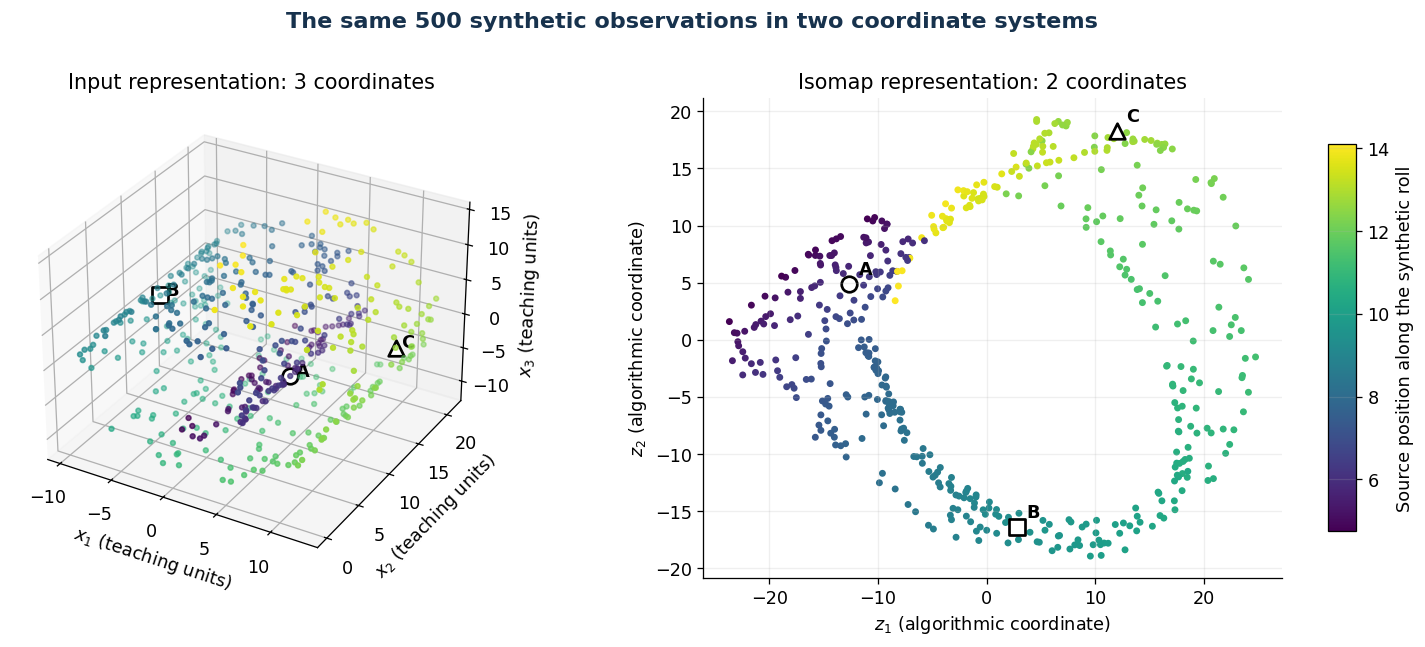

Representation,Shape,Coordinates,Known target used?
Original Swiss roll,"(500, 3)","original teaching coordinates x1, x2, x3",No
Isomap output,"(500, 2)","algorithmic output coordinates z1, z2",No


In [9]:
# Course-added dimensionality-reduction comparison.
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap

swiss_x, swiss_position = make_swiss_roll(n_samples=500, noise=0.08, random_state=STRUCTURE_SEED)
swiss_z = Isomap(n_neighbors=10, n_components=2).fit_transform(swiss_x)

fig = plt.figure(figsize=(13.5, 5.8))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax2d = fig.add_subplot(1, 2, 2)
ax3d.scatter(swiss_x[:, 0], swiss_x[:, 1], swiss_x[:, 2], c=swiss_position, cmap="viridis", s=9)
mapped_plot = ax2d.scatter(swiss_z[:, 0], swiss_z[:, 1], c=swiss_position, cmap="viridis", s=11)

anchor_positions = np.quantile(swiss_position, [0.15, 0.50, 0.85])
anchor_indices = [int(np.argmin(np.abs(swiss_position - value))) for value in anchor_positions]
for label, marker, index in zip(["A", "B", "C"], ["o", "s", "^"], anchor_indices):
    ax3d.scatter(
        swiss_x[index, 0], swiss_x[index, 1], swiss_x[index, 2],
        marker=marker, s=95, facecolors="white", edgecolors="black", linewidths=1.7,
    )
    ax3d.text(swiss_x[index, 0], swiss_x[index, 1], swiss_x[index, 2], f" {label}", weight="bold")
    ax2d.scatter(
        swiss_z[index, 0], swiss_z[index, 1],
        marker=marker, s=95, facecolors="white", edgecolors="black", linewidths=1.7,
    )
    ax2d.annotate(label, swiss_z[index], xytext=(6, 6), textcoords="offset points", weight="bold")

ax3d.set(
    title="Input representation: 3 coordinates",
    xlabel="$x_1$ (teaching units)",
    ylabel="$x_2$ (teaching units)",
    zlabel="$x_3$ (teaching units)",
)
ax2d.set(
    title="Isomap representation: 2 coordinates",
    xlabel="$z_1$ (algorithmic coordinate)",
    ylabel="$z_2$ (algorithmic coordinate)",
)
fig.suptitle("The same 500 synthetic observations in two coordinate systems", fontsize=14, weight="bold", color=DARK)
fig.subplots_adjust(left=0.03, right=0.88, top=0.85, bottom=0.13, wspace=0.28)
colorbar_axis = fig.add_axes([0.91, 0.20, 0.018, 0.58])
fig.colorbar(mapped_plot, cax=colorbar_axis, label="Source position along the synthetic roll")
plt.show()

representation_summary = pd.DataFrame(
    {
        "Representation": ["Original Swiss roll", "Isomap output"],
        "Shape": [str(swiss_x.shape), str(swiss_z.shape)],
        "Coordinates": ["original teaching coordinates x1, x2, x3", "algorithmic output coordinates z1, z2"],
        "Known target used?": ["No", "No"],
    }
)
show_table(representation_summary, "Input and output representations in the synthetic Swiss-roll example")

The array changes from shape (500, 3) to (500, 2). Anchors A-C identify the same observations in both panels, and the source-position color helps inspect whether the order along the roll remains organized. That color is not a target used to fit Isomap. The display establishes that a method can produce lower-dimensional coordinates; it does not establish that every distance is preserved or that Isomap is best for another dataset.

**Reasoning check.** If one feature is measured in dollars and another in years, what must be examined before Euclidean distance is treated as a meaningful similarity measure?

## Issue 4 - How does a dataset become a matrix?

The textbook uses the Iris dataset to establish its notation. Each row is one flower observation. The four measured features are sepal length, sepal width, petal length, and petal width in centimeters. The class target is one of three species.

The textbook prints the $150\times4$ Iris case. The following $n\times m$ form is the corresponding course-added generalization for $n$ observations and $m$ features:

$$
\mathbf{X}=
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} & \cdots & x_m^{(1)}\\
x_1^{(2)} & x_2^{(2)} & \cdots & x_m^{(2)}\\
\vdots & \vdots & \ddots & \vdots\\
x_1^{(n)} & x_2^{(n)} & \cdots & x_m^{(n)}
\end{bmatrix}
\in\mathbb{R}^{n\times m}.
$$

The superscript $(i)$ identifies an observation and the subscript $j$ identifies a feature. A complete row is

$$
\mathbf{x}^{(i)}=
\begin{bmatrix}
x_1^{(i)} & x_2^{(i)} & \cdots & x_m^{(i)}
\end{bmatrix}
\in\mathbb{R}^{1\times m},
$$

while feature $j$ across all observations is

$$
\mathbf{x}_j=
\begin{bmatrix}
x_j^{(1)}\\x_j^{(2)}\\\vdots\\x_j^{(n)}
\end{bmatrix}
\in\mathbb{R}^{n\times1}.
$$

If the target space is $\mathcal{Y}$, the targets are arranged as an $n\times1$ column

$$
\mathbf{y}=
\begin{bmatrix}
y^{(1)}\\y^{(2)}\\\vdots\\y^{(n)}
\end{bmatrix}
\in\mathcal{Y}^{n}.
$$

For Iris, $n=150$, $m=4$, $\mathbf{X}\in\mathbb{R}^{150\times4}$, and the label space is

$$
\mathcal{Y}=\{\text{Setosa},\text{Versicolor},\text{Virginica}\}.
$$

> **Reading check before viewing the schematic:** Name the four measurements that become columns of $\mathbf{X}$ and their units. Explain why the species name is not a fifth measured feature.

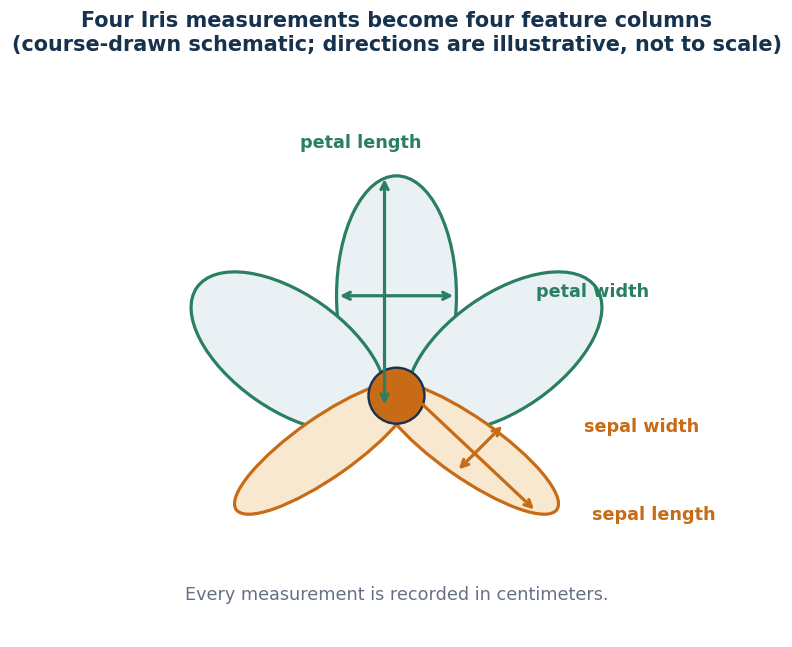

X column,Feature,Unit,NumPy selection
x1,sepal length,cm,"X[:, 0]"
x2,sepal width,cm,"X[:, 1]"
x3,petal length,cm,"X[:, 2]"
x4,petal width,cm,"X[:, 3]"


In [10]:
# Course-added Iris measurement schematic.
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_table = iris.frame.copy()
iris_table["species"] = iris_table["target"].map(dict(enumerate(iris.target_names)))
X = iris.data.to_numpy()
y = iris.target.to_numpy()

fig, ax = plt.subplots(figsize=(10.5, 6.5))
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-3.0, 4.2)
ax.set_aspect("equal")
ax.axis("off")

# Vector ellipses form a schematic flower; it is not a photograph or to scale.
for center, width, height, angle in [
    ((0.0, 1.25), 1.5, 3.0, 0),
    ((-1.35, 0.55), 1.45, 2.8, 55),
    ((1.35, 0.55), 1.45, 2.8, -55),
]:
    ax.add_patch(Ellipse(center, width, height, angle=angle, facecolor=LIGHT, edgecolor=ACCENT, linewidth=2.0))
for center, width, height, angle in [
    ((-0.9, -0.65), 0.75, 2.7, -55),
    ((0.9, -0.65), 0.75, 2.7, 55),
]:
    ax.add_patch(Ellipse(center, width, height, angle=angle, facecolor=WARM, edgecolor=SECONDARY, linewidth=2.0))
ax.add_patch(Ellipse((0, 0.0), 0.7, 0.7, facecolor=SECONDARY, edgecolor=DARK, linewidth=1.5))

ax.annotate("", xy=(-0.15, 2.75), xytext=(-0.15, -0.15), arrowprops={"arrowstyle": "<->", "color": ACCENT, "linewidth": 2})
ax.text(-0.45, 3.1, "petal length", color=ACCENT, weight="bold", ha="center")
ax.annotate("", xy=(0.75, 1.25), xytext=(-0.75, 1.25), arrowprops={"arrowstyle": "<->", "color": ACCENT, "linewidth": 2})
ax.text(1.75, 1.3, "petal width", color=ACCENT, weight="bold", va="center")

ax.annotate("", xy=(1.75, -1.45), xytext=(0.05, 0.15), arrowprops={"arrowstyle": "<->", "color": SECONDARY, "linewidth": 2})
ax.text(2.45, -1.55, "sepal length", color=SECONDARY, weight="bold")
ax.annotate("", xy=(1.35, -0.35), xytext=(0.75, -0.95), arrowprops={"arrowstyle": "<->", "color": SECONDARY, "linewidth": 2})
ax.text(2.35, -0.45, "sepal width", color=SECONDARY, weight="bold")

ax.set_title(
    "Four Iris measurements become four feature columns\n"
    "(course-drawn schematic; directions are illustrative, not to scale)",
    weight="bold",
    color=DARK,
)
ax.text(0, -2.55, "Every measurement is recorded in centimeters.", ha="center", color=MUTED)
plt.show()

feature_dictionary = pd.DataFrame(
    {
        "X column": ["x1", "x2", "x3", "x4"],
        "Feature": ["sepal length", "sepal width", "petal length", "petal width"],
        "Unit": ["cm"] * 4,
        "NumPy selection": ["X[:, 0]", "X[:, 1]", "X[:, 2]", "X[:, 3]"],
    }
)
show_table(feature_dictionary, "Columns of the Iris feature matrix X")

The schematic and dictionary connect each physical measurement to one column of $\mathbf{X}$. The arrows show the meanings of length and width schematically; they are not a field measurement protocol. Species is the prediction target, so it is recorded in $\mathbf{y}$ and excluded from the four measured feature columns.

> **Before running the next cell:** Predict which side of the dashed boundary belongs to $\mathbf{X}$ and which belongs to $\mathbf{y}$. For observation 150, predict whether the species label should appear inside the four-feature bracket.

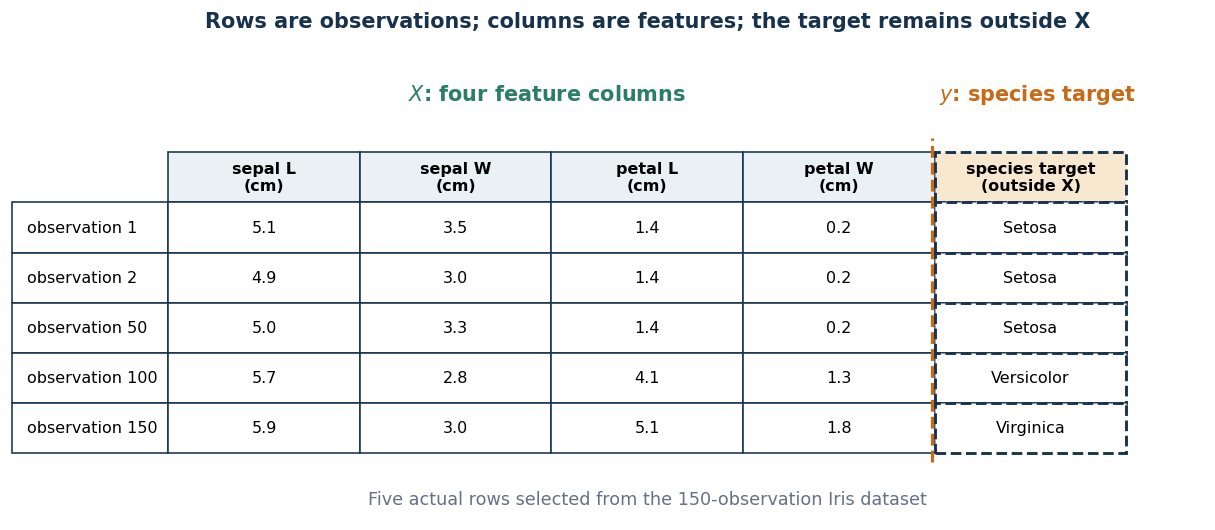

Observation,Sepal L (cm),Sepal W (cm),Petal L (cm),Petal W (cm),Species
1,5.1,3.5,1.4,0.2,Setosa
2,4.9,3.0,1.4,0.2,Setosa
50,5.0,3.3,1.4,0.2,Setosa
100,5.7,2.8,4.1,1.3,Versicolor
150,5.9,3.0,5.1,1.8,Virginica


In [11]:
# Course-added Iris matrix-and-target schematic.
selected_rows = np.array([0, 1, 49, 99, 149])
selected_values = [
    [*(f"{value:.1f}" for value in X[row_index]), iris.target_names[y[row_index]].title()]
    for row_index in selected_rows
]

fig, ax = plt.subplots(figsize=(12.5, 5.3))
ax.axis("off")
matrix_table = ax.table(
    cellText=selected_values,
    colLabels=["sepal L\n(cm)", "sepal W\n(cm)", "petal L\n(cm)", "petal W\n(cm)", "species target\n(outside X)"],
    rowLabels=[f"observation {index + 1}" for index in selected_rows],
    cellLoc="center",
    colLoc="center",
    bbox=[0.07, 0.14, 0.86, 0.64],
)
matrix_table.auto_set_font_size(False)
matrix_table.set_fontsize(10)
for (row, column), table_cell in matrix_table.get_celld().items():
    table_cell.set_edgecolor(DARK)
    if row == 0:
        table_cell.set_facecolor(LIGHT if column < 4 else WARM)
        table_cell.set_text_props(weight="bold")
    if column == 4:
        table_cell.set_linestyle("--")
        table_cell.set_linewidth(1.8)

ax.plot([0.756, 0.756], [0.12, 0.81], transform=ax.transAxes, color=SECONDARY, linestyle="--", linewidth=2.0)
ax.text(0.41, 0.89, "$X$: four feature columns", transform=ax.transAxes, ha="center", fontsize=13, weight="bold", color=ACCENT)
ax.text(0.85, 0.89, "$y$: species target", transform=ax.transAxes, ha="center", fontsize=13, weight="bold", color=SECONDARY)
ax.text(0.50, 0.03, "Five actual rows selected from the 150-observation Iris dataset", transform=ax.transAxes, ha="center", color=MUTED)
ax.set_title("Rows are observations; columns are features; the target remains outside X", weight="bold", color=DARK, pad=14)
plt.show()

selected_observations = pd.DataFrame(
    {
        "Observation": selected_rows + 1,
        "Sepal L (cm)": X[selected_rows, 0],
        "Sepal W (cm)": X[selected_rows, 1],
        "Petal L (cm)": X[selected_rows, 2],
        "Petal W (cm)": X[selected_rows, 3],
        "Species": [iris.target_names[value].title() for value in y[selected_rows]],
    }
)
show_table(
    selected_observations,
    "Five selected observations from the 150-observation Iris dataset",
    {
        "Sepal L (cm)": "{:.1f}",
        "Sepal W (cm)": "{:.1f}",
        "Petal L (cm)": "{:.1f}",
        "Petal W (cm)": "{:.1f}",
    },
)

The four feature columns lie to the left of the dashed boundary. Species lies to the right in $\mathbf{y}$, so it is not a fifth feature. Observation 150 has measurements 5.9, 3.0, 5.1, and 1.8 centimeters and the target Virginica. These are the values returned by the scikit-learn dataset used in the executed notebook. The publisher's schematic Figure 1.8 displays 5.0 for that petal-length entry; the notebook reports the executed data value rather than silently replacing it. The flower drawing above is only a schematic explanation of what the columns measure.

> **Before running the next cell:** Predict the NumPy shapes of X, X[149:150, :], X[:, 0], X[:, 0:1], y, and y[:, None]. Which expressions retain two dimensions, and which are rank-1 arrays with no row-or-column orientation?

In [12]:
shape_check = pd.DataFrame(
    {
        "Expression": ["X", "X[149:150, :]", "X[:, 0]", "X[:, 0:1]", "y", "y[:, None]"],
        "Role": [
            "feature matrix",
            "observation 150 as a row matrix",
            "feature 1 as a rank-1 array",
            "feature 1 as a column matrix",
            "targets as a rank-1 array",
            "targets as a column matrix",
        ],
        "Shape": [
            str(X.shape),
            str(X[149:150, :].shape),
            str(X[:, 0].shape),
            str(X[:, 0:1].shape),
            str(y.shape),
            str(y[:, None].shape),
        ],
    }
)
show_table(shape_check, "Iris array expressions and their mathematical shapes")

target_dictionary = pd.DataFrame(
    {
        "Code": np.arange(len(iris.target_names)),
        "Species": [name.title() for name in iris.target_names],
        "Role": ["class target"] * len(iris.target_names),
    }
)
show_table(target_dictionary, "Meaning of the Iris integer codes in y; codes are nominal labels, not distances")

Expression,Role,Shape
X,feature matrix,"(150, 4)"
"X[149:150, :]",observation 150 as a row matrix,"(1, 4)"
"X[:, 0]",feature 1 as a rank-1 array,"(150,)"
"X[:, 0:1]",feature 1 as a column matrix,"(150, 1)"
y,targets as a rank-1 array,"(150,)"
"y[:, None]",targets as a column matrix,"(150, 1)"


Code,Species,Role
0,Setosa,class target
1,Versicolor,class target
2,Virginica,class target


The shape table verifies that X has shape (150, 4). Observation 150 remains two-dimensional when written as X[149:150, :], with shape (1, 4). NumPy's X[:, 0] and y both have shape (150,), so these rank-1 arrays have no row-or-column orientation. Range slicing X[:, 0:1] and adding an axis with y[:, None] produce shape (150, 1), matching the mathematical column-vector notation. Python uses zero-based indexing, so mathematical observation 150 appears at index 149. The target codes 0-2 are implementation conveniences; numerical operations on them do not define biological distance among species.

**Reasoning check.** A table has 20,000 transactions from 2,500 customers. Before declaring $n=20{,}000$, what is the intended observation unit, and how could repeated customers affect a train/test split?

## Issue 5 - Where is the boundary between fitting and final evaluation?

The Iris rows in Issue 4 were displayed to teach data notation. The later split illustrates an evaluation procedure on this familiar teaching dataset; it is not a claim that the author has never seen the held-out observations. In your own project, decide the evaluation design before using data to choose features, preprocessing, or models, and keep the test portion out of those choices.

A predictive workflow is more than a learning algorithm:

1. define the intended use, observation unit, features, target, and error consequences;
2. collect and inspect authorized data;
3. reserve a test set that represents the intended future use;
4. use the remaining development data to fit preprocessing, compare models, and choose hyperparameters;
5. apply the completed procedure to the reserved test set for final evaluation; and
6. apply the same fitted preprocessing and model to new observations.

The next three figures separate development, final evaluation, and future prediction so that each information boundary remains readable.

Establishing a split and developing a model have different purposes. A stratified split may use class labels to assign observations to subsets with similar class proportions, provided that this rule is chosen in advance. This use of labels to construct the split does not permit fitting transformations on the test portion, selecting features from it, or changing the split after inspecting model scores. For grouped or time-ordered observations, the split must also respect the intended deployment setting.

> **Before running the next cell:** Predict which data may repeatedly influence preprocessing, fitting, and candidate selection. Identify the stage at which changing the procedure is still allowed.

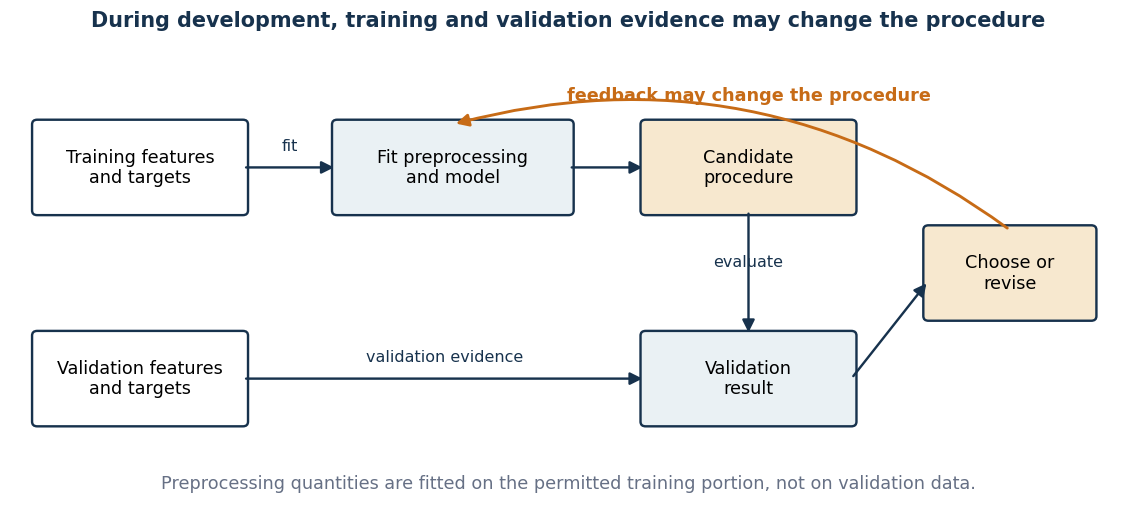

In [13]:
# Course-added development-feedback diagram.
fig, ax = plt.subplots(figsize=(12.5, 5.3))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis("off")

draw_box(ax, 0.3, 3.9, 2.4, 1.1, "Training features\nand targets", facecolor="white")
draw_box(ax, 0.3, 1.2, 2.4, 1.1, "Validation features\nand targets", facecolor="white")
draw_box(ax, 3.8, 3.9, 2.7, 1.1, "Fit preprocessing\nand model", facecolor=LIGHT)
draw_box(ax, 7.4, 3.9, 2.4, 1.1, "Candidate\nprocedure", facecolor=WARM)
draw_box(ax, 7.4, 1.2, 2.4, 1.1, "Validation\nresult", facecolor=LIGHT)
draw_box(ax, 10.7, 2.55, 1.9, 1.1, "Choose or\nrevise", facecolor=WARM)

draw_arrow(ax, (2.7, 4.45), (3.8, 4.45), "fit")
draw_arrow(ax, (6.5, 4.45), (7.4, 4.45))
draw_arrow(ax, (8.6, 3.9), (8.6, 2.3), "evaluate", label_offset=0.05)
draw_arrow(ax, (2.7, 1.75), (7.4, 1.75), "validation evidence")
draw_arrow(ax, (9.8, 1.75), (10.7, 3.0))
feedback_arrow = FancyArrowPatch(
    (11.65, 3.65),
    (5.15, 5.0),
    connectionstyle="arc3,rad=0.24",
    arrowstyle="-|>",
    mutation_scale=16,
    linewidth=1.8,
    color=SECONDARY,
)
ax.add_patch(feedback_arrow)
ax.text(8.6, 5.30, "feedback may change the procedure", ha="center", color=SECONDARY, weight="bold")

ax.set_title("During development, training and validation evidence may change the procedure", weight="bold", color=DARK, pad=12)
ax.text(6.5, 0.35, "Preprocessing quantities are fitted on the permitted training portion, not on validation data.", ha="center", color=MUTED)
plt.show()

Training data may fit preprocessing and model parameters. Validation data may compare candidates and send the team back to revise the procedure. The validation targets support evaluation, but they are not inputs to the model's predictions. Because this feedback is expected, validation evidence is development evidence.

> **Before running the next cell:** Once the split has been established, identify the permitted uses of test features and test targets in final evaluation. Which feedback arrow must be absent if test results are to remain separate from model selection?

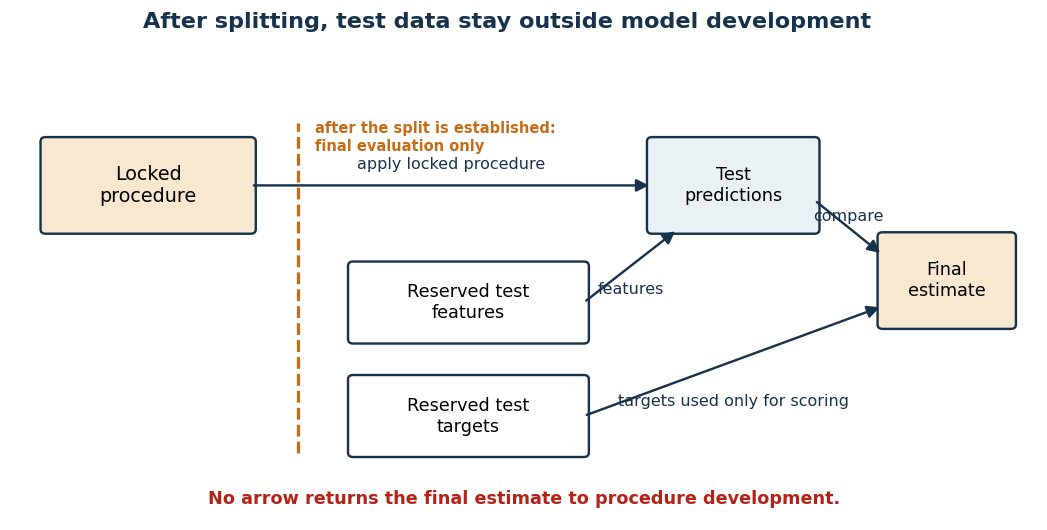

In [14]:
# Course-added final-evaluation boundary.
fig, ax = plt.subplots(figsize=(11.5, 4.9))
ax.set_xlim(0, 12)
ax.set_ylim(-0.55, 5.3)
ax.axis("off")

draw_box(ax, 0.4, 3.4, 2.4, 1.2, "Locked\nprocedure", facecolor=WARM, fontsize=12)
draw_box(ax, 4.0, 1.9, 2.7, 1.0, "Reserved test\nfeatures", facecolor="white")
draw_box(ax, 4.0, 0.35, 2.7, 1.0, "Reserved test\ntargets", facecolor="white")
draw_box(ax, 7.5, 3.4, 1.9, 1.2, "Test\npredictions", facecolor=LIGHT)
draw_box(ax, 10.2, 2.1, 1.5, 1.2, "Final\nestimate", facecolor=WARM)

draw_arrow(ax, (2.8, 4.0), (7.5, 4.0), "apply locked procedure")
draw_arrow(ax, (6.7, 2.4), (7.8, 3.4), "features", label_offset=-0.42)
draw_arrow(ax, (6.7, 0.85), (10.2, 2.35), "targets used only for scoring", label_offset=-0.65)
draw_arrow(ax, (9.4, 3.8), (10.2, 3.05), "compare", label_offset=0.05)

ax.plot([3.35, 3.35], [0.35, 4.85], linestyle="--", color=SECONDARY, linewidth=2.0)
ax.text(
    3.55,
    4.88,
    "after the split is established:\nfinal evaluation only",
    ha="left",
    va="top",
    color=SECONDARY,
    fontsize=9.2,
    weight="bold",
)
ax.text(6.0, -0.35, "No arrow returns the final estimate to procedure development.", ha="center", color=DANGER, weight="bold")
fig.suptitle("After splitting, test data stay outside model development", fontsize=14, weight="bold", color=DARK, y=0.98)
fig.subplots_adjust(top=0.84, bottom=0.08)
plt.show()

The test features produce predictions only after the procedure is locked. Test targets are then compared with those predictions to calculate the final estimate. There is deliberately no arrow from the estimate back to development. If the team changes features, preprocessing, candidates, or hyperparameters after inspecting this result, the test set has begun to serve as development evidence.

> **Before running the next cell:** Predict which fitted objects must be reused for a future observation and whether its true target is available when the prediction is made.

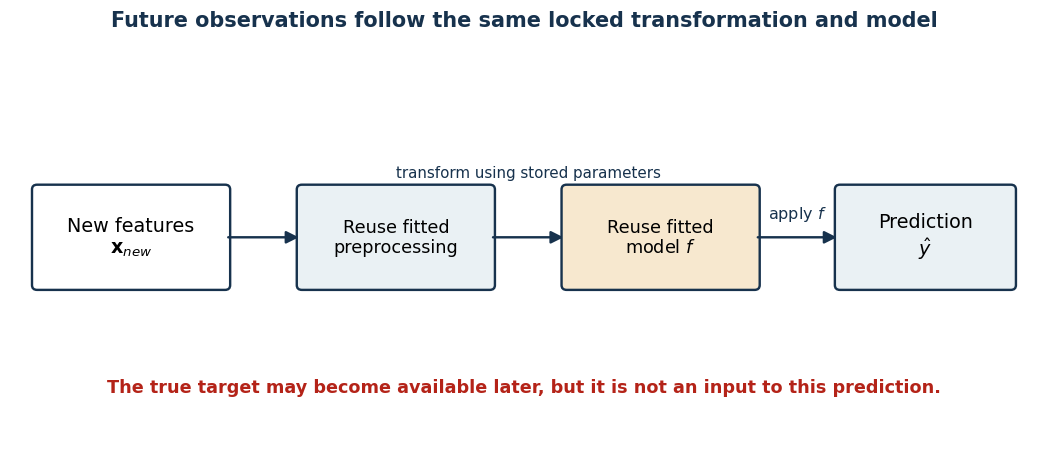

In [15]:
# Course-added future-prediction path.
fig, ax = plt.subplots(figsize=(11.5, 4.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

draw_box(ax, 0.3, 2.0, 2.2, 1.2, "New features\n$\\mathbf{x}_{new}$", facecolor="white", fontsize=12)
draw_box(ax, 3.4, 2.0, 2.2, 1.2, "Reuse fitted\npreprocessing", facecolor=LIGHT)
draw_box(ax, 6.5, 2.0, 2.2, 1.2, "Reuse fitted\nmodel $f$", facecolor=WARM)
draw_box(ax, 9.7, 2.0, 2.0, 1.2, "Prediction\n$\\hat y$", facecolor=LIGHT, fontsize=12)

draw_arrow(ax, (2.5, 2.6), (3.4, 2.6))
draw_arrow(ax, (5.6, 2.6), (6.5, 2.6))
ax.text(6.05, 3.35, "transform using stored parameters", ha="center", color=DARK, fontsize=9.5)
draw_arrow(ax, (8.7, 2.6), (9.7, 2.6), "apply $f$")

ax.text(6.0, 0.65, "The true target may become available later, but it is not an input to this prediction.", ha="center", color=DANGER, weight="bold")
ax.set_title("Future observations follow the same locked transformation and model", weight="bold", color=DARK, pad=12)
plt.show()

New features pass through the same fitted preprocessing and model used in the completed procedure. Re-estimating preprocessing from one new observation would change the representation and would no longer apply the same procedure. The true target is unavailable at prediction time; it may become available later for monitoring, or it may never be observed.

In [16]:
information_use = pd.DataFrame(
    {
        "Stage": ["Training", "Validation", "Final evaluation", "New prediction"],
        "Feature data": ["training", "validation", "reserved test", "new observation"],
        "Targets": ["used for fitting", "used for comparison", "used only for final scoring", "unavailable at prediction time"],
        "Permitted action": ["Fit", "Select or revise", "Final scoring only", "Predict only"],
        "Output": ["fitted candidate", "locked procedure", "final test estimate", "prediction"],
    }
)
show_table(information_use, "Information allowed at each stage of predictive modeling")

Stage,Feature data,Targets,Permitted action,Output
Training,training,used for fitting,Fit,fitted candidate
Validation,validation,used for comparison,Select or revise,locked procedure
Final evaluation,reserved test,used only for final scoring,Final scoring only,final test estimate
New prediction,new observation,unavailable at prediction time,Predict only,prediction


The table separates the two uses of development evidence: training data may fit a candidate, while validation data may compare candidates and trigger revision. Reserved test data do neither. The figures do not prescribe one split ratio or validation method; they specify which information may influence which decision.

### Train-fitted scaling

The textbook states that test and future observations must reuse transformations fitted on training data. The equations below are course-added expansions of that requirement.

If feature $j$ is standardized, its training mean and standard deviation are

$$
\mu_j^{\text{train}}=\frac{1}{n_{\text{train}}}
\sum_{i\in\text{train}}x_j^{(i)},
$$

$$
\sigma_j^{\text{train}}=
\sqrt{\frac{1}{n_{\text{train}}}
\sum_{i\in\text{train}}
\left(x_j^{(i)}-\mu_j^{\text{train}}\right)^2}.
$$

The denominator $n_{\text{train}}$ defines the population-form standard deviation of this finite training array and matches NumPy's `std(ddof=0)`; it does not claim that the training data are the complete real-world population. The feature value, mean, and standard deviation have the original feature unit. For a nonconstant feature with $\sigma_j^{\text{train}}>0$, observation $i$ is transformed as

$$
z_j^{(i)}=\frac{x_j^{(i)}-\mu_j^{\text{train}}}{\sigma_j^{\text{train}}}.
$$

The standardized value $z_j^{(i)}$ is dimensionless. While comparing candidates, fit these quantities on the training portion and reuse them on validation observations. After selecting a procedure, you may refit its preprocessing and model on all development observations, as demonstrated in Issue 6. Test and future observations must then use the parameters from that final fit. In either stage, evaluation observations do not contribute to the fitted scaling quantities. For min-max scaling, the corresponding train-fitted formula is

$$
x_j'^{(i)}=\frac{x_j^{(i)}-\min_{r\in\text{train}}x_j^{(r)}}
{\max_{r\in\text{train}}x_j^{(r)}-\min_{r\in\text{train}}x_j^{(r)}}.
$$

The min-max formula is dimensionless and requires a nonzero training range. It maps the smallest and largest training values to 0 and 1. A validation, test, or future value outside that training range can legitimately transform below 0 or above 1. A constant feature makes either scaling denominator zero and must be handled explicitly. If test observations help determine any fitted quantity, information from final evaluation has entered development. This is data leakage even when test targets are not used.

> **Before running the next cell:** The artificial test value 100 is far outside training values [1, 2, 3, 4]. Predict whether including 100 when calculating the mean and standard deviation will make the same test value appear more or less extreme after standardization.

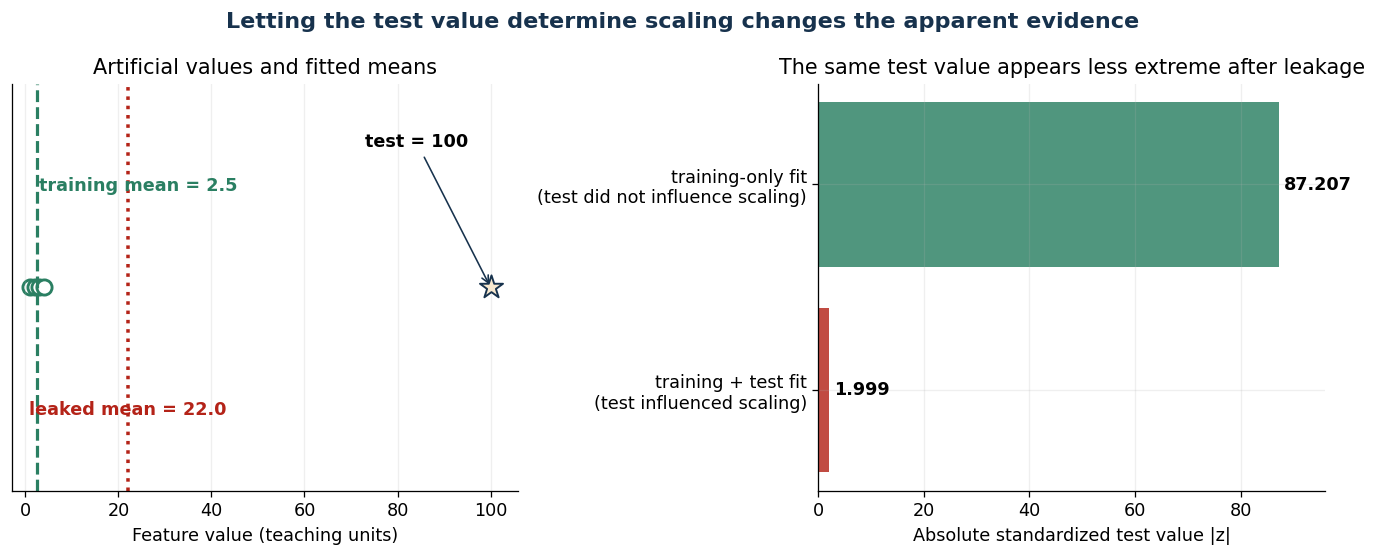

Fitting data,Mean (teaching units),SD (teaching units),Test z (dimensionless),Valid final-evaluation procedure?
"training only: [1, 2, 3, 4]",2.500,1.118,87.207,Yes
"training + test: [1, 2, 3, 4, 100]",22.000,39.013,1.999,No - test influenced scaling


In [17]:
# Artificial teaching example: the value 100 is deliberately outside the training range.
train_feature = np.array([1.0, 2.0, 3.0, 4.0])
test_feature = np.array([100.0])

leak_train_mean = train_feature.mean()
leak_train_std = train_feature.std(ddof=0)
correct_test_z = (test_feature[0] - leak_train_mean) / leak_train_std

all_values = np.concatenate([train_feature, test_feature])
leak_all_mean = all_values.mean()
leak_all_std = all_values.std(ddof=0)
leaked_test_z = (test_feature[0] - leak_all_mean) / leak_all_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9))
axes[0].scatter(train_feature, np.zeros_like(train_feature), marker="o", s=90, facecolors="white", edgecolors=ACCENT, linewidths=1.8)
axes[0].scatter(test_feature, [0], marker="*", s=230, color=WARM, edgecolor=DARK, linewidth=1.2, zorder=4)
axes[0].axvline(leak_train_mean, color=ACCENT, linestyle="--", linewidth=2.0)
axes[0].axvline(leak_all_mean, color=DANGER, linestyle=":", linewidth=2.2)
axes[0].text(3.0, 0.38, f"training mean = {leak_train_mean:.1f}", color=ACCENT, ha="left", weight="bold")
axes[0].text(leak_all_mean, -0.50, f"leaked mean = {leak_all_mean:.1f}", color=DANGER, ha="center", weight="bold")
axes[0].annotate("test = 100", (100, 0), xytext=(73, 0.55), arrowprops={"arrowstyle": "->", "color": DARK}, weight="bold")
axes[0].set(
    title="Artificial values and fitted means",
    xlabel="Feature value (teaching units)",
    yticks=[],
    xlim=(-3, 106),
    ylim=(-0.8, 0.8),
)

labels = [
    "training-only fit\n(test did not influence scaling)",
    "training + test fit\n(test influenced scaling)",
]
z_values = [abs(correct_test_z), abs(leaked_test_z)]
bars = axes[1].barh(labels, z_values, color=[ACCENT, DANGER], alpha=0.82)
axes[1].invert_yaxis()
axes[1].set_xlabel("Absolute standardized test value |z|")
axes[1].set_title("The same test value appears less extreme after leakage")
for bar, value in zip(bars, z_values):
    axes[1].text(value + 1.0, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", weight="bold")
axes[1].set_xlim(0, 96)

fig.suptitle("Letting the test value determine scaling changes the apparent evidence", fontsize=14, weight="bold", color=DARK)
fig.tight_layout()
plt.show()

leakage_table = pd.DataFrame(
    {
        "Fitting data": ["training only: [1, 2, 3, 4]", "training + test: [1, 2, 3, 4, 100]"],
        "Mean (teaching units)": [leak_train_mean, leak_all_mean],
        "SD (teaching units)": [leak_train_std, leak_all_std],
        "Test z (dimensionless)": [correct_test_z, leaked_test_z],
        "Valid final-evaluation procedure?": ["Yes", "No - test influenced scaling"],
    }
)
show_table(
    leakage_table,
    "Effect of allowing the artificial test value to determine scaling",
    {"Mean (teaching units)": "{:.3f}", "SD (teaching units)": "{:.3f}", "Test z (dimensionless)": "{:.3f}"},
)

With training-only fitting, the mean is 2.500, the standard deviation is 1.118, and the test value lies 87.207 training standard deviations above the training mean. When the test value is improperly included, the mean changes to 22.000, the standard deviation changes to 39.013, and the same value lies only 1.999 standard deviations above that improperly fitted mean. The artificial example is deliberately exaggerated so that the mechanism is visible. It does not estimate how much leakage will change a real model.

The same boundary applies to imputation, feature selection, dimensionality reduction, and other operations that learn quantities from data: fit them on the permitted training portion, then reuse the fitted transformation elsewhere.

**Reasoning check.** Why is "we never used the test labels" insufficient evidence that preprocessing was leakage-free?

## Issue 6 - What does an evaluation number mean?

Training performance describes data used to fit parameters. Validation performance supports comparisons among candidate procedures. Test performance estimates how the already selected procedure behaves on reserved observations. Reusing one set for all three purposes weakens the interpretation.

For classification, the textbook defines accuracy verbally as the proportion classified correctly. The following equation is the course-added mathematical form:

$$
\operatorname{Accuracy}
=\frac{\text{number of correctly classified observations}}
{\text{number of evaluated observations}}
=\frac{1}{n_{\text{eval}}}\sum_{i=1}^{n_{\text{eval}}}\mathbb{1}\!\left(y^{(i)}=\hat y^{(i)}\right),
$$

where $n_{\text{eval}}>0$ is the number of evaluated observations and $\mathbb{1}(\cdot)$ equals 1 when the statement is true and 0 otherwise. Accuracy is dimensionless, weights every evaluated observation equally, and can conceal which classes are harmed or which mistakes have greater consequences.

For classification, one possible loss for a single observation is the dimensionless 0-1 loss

$$
L_{0\text{-}1}\!\left(y^{(i)},\hat y^{(i)}\right)
=\mathbb{1}\!\left(y^{(i)}\ne\hat y^{(i)}\right).
$$

More generally, let $L$ map a target-prediction pair to a nonnegative number. A finite test-set average loss is the course-added expression

$$
\widehat{R}_{\text{test}}
=\frac{1}{n_{\text{test}}}
\sum_{i\in\text{test}}L\!\left(y^{(i)},\hat y^{(i)}\right).
$$

Here, each $\hat y^{(i)}$ must be produced by the complete locked procedure, including any fitted preprocessing and the fitted model. The units of $\widehat{R}_{\text{test}}$ are determined by the chosen loss $L$; with 0-1 loss it is a dimensionless error proportion. Both averages require a nonempty evaluation set. The test average is an estimate for data represented by the test design, not a guarantee for every future population. The no-free-lunch result discussed in the chapter rules out a universally best learning algorithm when no assumptions about the task are made.

When one class represents the condition that must not be missed, accuracy should be accompanied by an error count or rate for that class. If the positive class is the condition of interest, the false-negative rate is

$$
\operatorname{FNR}=\frac{\mathrm{FN}}{\mathrm{TP}+\mathrm{FN}},
$$

where $\mathrm{FN}$ is the number of actual positive observations predicted negative and $\mathrm{TP}$ is the number of actual positive observations predicted positive. The denominator is the number of actual positive observations and must be greater than zero. The false-negative rate is dimensionless and answers a different question from overall accuracy.

The next demonstration treats logistic regression and 5-nearest neighbors as candidate procedures without explaining their internal algorithms. Its purpose is to examine training, validation, and test evidence. Later chapters derive the models and Chapter 6 develops model evaluation in detail.

> **Before running the next cell:** The demonstration uses only Iris sepal length and width, which overlap across species. Predict which candidate will have higher validation accuracy. Also predict whether the highest training accuracy must identify the selected candidate. An exact tie is resolved by the first predeclared candidate only to keep the execution deterministic.

In [18]:
# Course-added workflow preview. Model internals and detailed selection are deferred to later chapters.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_two = X[:, :2]
X_development, X_test, y_development, y_test = train_test_split(
    X_two, y, test_size=0.20, random_state=SPLIT_SEED, stratify=y
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development, y_development, test_size=0.20, random_state=SPLIT_SEED, stratify=y_development
)

model_train_mean = X_train.mean(axis=0)
model_train_std = X_train.std(axis=0, ddof=0)
X_train_z = (X_train - model_train_mean) / model_train_std
X_validation_z = (X_validation - model_train_mean) / model_train_std

candidates = {
    "logistic regression": LogisticRegression(max_iter=1000),
    "5-nearest neighbors": KNeighborsClassifier(n_neighbors=5),
}

rows = []
for name, model in candidates.items():
    model.fit(X_train_z, y_train)
    training_predictions = model.predict(X_train_z)
    validation_predictions = model.predict(X_validation_z)
    training_correct = int(np.sum(training_predictions == y_train))
    validation_correct = int(np.sum(validation_predictions == y_validation))
    rows.append(
        {
            "Candidate": name,
            "Training correct (n=96)": training_correct,
            "Training accuracy": training_correct / len(y_train),
            "Validation correct (n=24)": validation_correct,
            "Validation accuracy": validation_correct / len(y_validation),
        }
    )

comparison = pd.DataFrame(rows).sort_values(
    "Validation accuracy", ascending=False, kind="stable"
).reset_index(drop=True)
selected_name = comparison.loc[0, "Candidate"]
comparison["Selected by tie rule?"] = np.where(comparison["Candidate"] == selected_name, "Yes", "No")

show_table(
    comparison,
    "Two-feature Iris candidate evidence on one fixed split; validation ties use the first predeclared candidate",
    {"Training accuracy": "{:.3f}", "Validation accuracy": "{:.3f}"},
)

Candidate,Training correct (n=96),Training accuracy,Validation correct (n=24),Validation accuracy,Selected by tie rule?
logistic regression,80,0.833,22,0.917,Yes
5-nearest neighbors,81,0.844,22,0.917,No


Both candidates correctly classify 22 of 24 validation observations, so each has validation accuracy $22/24=0.917$. Five-nearest neighbors correctly classifies 81 of 96 training observations, compared with 80 of 96 for logistic regression, giving training accuracies 0.844 and 0.833. Training accuracy is not the declared selection criterion. The predeclared tie rule therefore selects logistic regression. The tie does not establish that logistic regression is the better algorithm. `stratify=y` and `stratify=y_development` make each split preserve the three class proportions as closely as the requested integer split sizes permit; this matters here because otherwise a candidate might be evaluated on a noticeably different class mixture by chance.

### Refitting after model selection

During candidate comparison, only the 96 training observations fitted the scaling quantities and model parameters; the 24 validation observations were used to choose the procedure. After that choice, the validation portion has finished its selection role. We now use all 120 development observations as the training data for the final fit. Recalculate the scaling quantities from those 120 observations, refit the selected model with the chosen hyperparameters, and apply that fitted transformation and model to the 30 reserved test observations.

This refitting is permitted because the test portion still has no influence on fitting or selection. The earlier validation score describes the candidate fitted on 96 observations; it is not a fresh evaluation of the model refitted on 120. Here, locking the procedure means fixing the features, preprocessing method, candidate choice, hyperparameters, and refitting plan before final test evaluation. The fitted numerical parameters can change during the planned refit.

> **Before running the next cell:** The selected procedure will now be refitted on all 120 development observations and evaluated once on 30 reserved test observations. Predict whether its test accuracy must equal the validation accuracy.

In [19]:
# Final evaluation occurs only after the candidate and tie rule are fixed.
development_mean = X_development.mean(axis=0)
development_std = X_development.std(axis=0, ddof=0)
X_development_z = (X_development - development_mean) / development_std
X_test_z = (X_test - development_mean) / development_std

selected_model = candidates[selected_name]
selected_model.fit(X_development_z, y_development)
test_predictions = selected_model.predict(X_test_z)
test_correct = int(np.sum(test_predictions == y_test))
test_accuracy = test_correct / len(y_test)

final_result = pd.DataFrame(
    {
        "Selected procedure": [selected_name],
        "Development n": [len(y_development)],
        "Test correct": [test_correct],
        "Test n": [len(y_test)],
        "Test accuracy": [test_accuracy],
    }
)
show_table(
    final_result,
    "Two-feature Iris final evaluation on the fixed split; the procedure was selected before reserved test evaluation",
    {"Test accuracy": "{:.3f}"},
)

Selected procedure,Development n,Test correct,Test n,Test accuracy
logistic regression,120,21,30,0.700


After refitting on all development data, logistic regression correctly classifies 21 of 30 reserved test observations, for test accuracy $21/30=0.700$. The corresponding 0-1 test loss is $9/30=0.300$, and $0.700=1-0.300$. This differs from validation accuracy 0.917; equality was never guaranteed. Read 0.700 as one estimate under this exact split, two-feature representation, candidate list, and tie rule, not as proof of general superiority. Chapter 6 will add cross-validation, uncertainty, tuning, and a broader set of metrics.

**Reasoning check.** If you inspect the test result and then change the features or candidate list, what role has the test set begun to play? What new evidence would be required for an untouched final estimate?

## Issue 7 - Can another person reproduce the environment and the claim?

The textbook was written against an earlier software environment. Exact version matching is sometimes useful for reproducing published code, but a course notebook should also record the environment in which its current outputs were actually produced.

This semester's approved scope is Chapters 1-10. Those chapters primarily use Python, NumPy, pandas, Matplotlib, SciPy, and scikit-learn. PyTorch begins later in the textbook and is not required for this machine-learning semester unless the instructor changes the scope.

Run the following cell without editing its output. If your versions differ, differences are not automatically errors; they are evidence to preserve when numerical or API behavior changes.

In [20]:
environment_table = pd.DataFrame(
    {
        "Component": ["Python", "NumPy", "pandas", "SciPy", "scikit-learn", "Matplotlib", "Platform", "Random seeds"],
        "Verified version or value": [
            platform.python_version(),
            np.__version__,
            pd.__version__,
            scipy.__version__,
            sklearn.__version__,
            matplotlib.__version__,
            platform.platform(),
            f"classification={CLASSIFICATION_SEED}; structure={STRUCTURE_SEED}; splits={SPLIT_SEED}",
        ],
    }
)
show_table(environment_table, "Environment used to generate the preserved outputs")

Component,Verified version or value
Python,3.12.9
NumPy,2.2.6
pandas,2.2.3
SciPy,1.17.1
scikit-learn,1.8.0
Matplotlib,3.10.8
Platform,Windows-11-10.0.26200-SP0
Random seeds,classification=7; structure=11; splits=17


In this executed reference run, the preserved output was produced with Python 3.12.9, NumPy 2.2.6, pandas 2.2.3, SciPy 1.17.1, scikit-learn 1.8.0, and Matplotlib 3.10.8. The table above is generated from the active runtime, so a later rerun may report different values. These are not the publication-era versions listed in the textbook. Versions alone are not enough. Preserve the data source and date, observation unit, target definition, feature transformations, split procedure, purpose-specific random seeds, candidate procedures, selection rule, metric, actual outputs, and known limitations.

If you create a local virtual environment, use either venv with pip or a conda-compatible environment manager. Do not mix installation commands into analytical cells. Environment creation should occur before the notebook is opened, and package changes should be recorded rather than silently applied while results are being produced.

<details>
<summary>One Windows venv setup route</summary>

Run these commands in a terminal from the folder where you want the environment. They are setup commands, not notebook cells.

    python -m venv .venv
    .\.venv\Scripts\Activate.ps1
    python -m pip install --upgrade pip
    python -m pip install numpy scipy pandas matplotlib scikit-learn jupyterlab
    python -m jupyter lab

If PowerShell policy prevents activation, do not weaken the computer's security settings. Use the environment's Python executable directly or ask the instructor which managed environment is available.

</details>

## Two integrative discussion questions

### Question 1 - Is the final number still a test estimate?

A team reports 98% training accuracy, 92% validation accuracy, and 87% test accuracy. It then reveals that missing-value replacement, scaling, and a feature-selection rule that used feature-target associations were all fitted once on the complete dataset before the split. Can the 87% value still be presented as an untouched estimate of generalization? Identify every information-boundary violation, specify exactly what must be rerun, and state what evidence would allow a new final estimate to be interpreted.

### Question 2 - Define the learning problem before choosing a model

A university has 12,000 historical course-enrollment records from 4,100 students. It wants to identify, before Week 3, enrollments that may end in withdrawal so that an adviser can offer support. Define the observation unit, $\mathbf{X}$, $\mathbf{y}$, prediction time, and learning type. Then specify a split that prevents the same student's records from making evaluation artificially easy and explain how the false-negative rate would be calculated for withdrawal. For one incorrect prediction, state whether it is a false positive or false negative, identify the resulting adviser action, and describe one plausible harm. Finally, state one finding that should stop deployment even if validation accuracy is high.

## Evidence to preserve

Keep your written predictions from before execution, the executed notebook with its tables and figures, the environment table, and short answers to the reasoning checks. For your project record, add one candidate problem with an observation unit, possible features, a target or other learning signal, the time at which a prediction or action would occur, and one reason the available data may not support the intended use.

## Chapter summary

Machine learning begins with a learning signal, a defined observation, and a claim that can be checked on data not used to fit the procedure. Supervised learning predicts known targets; classification predicts categories and regression predicts continuous quantities. Unsupervised learning can expose structure without known targets, while reinforcement learning concerns actions and rewards across interactions. Matrix notation makes the data arrangement explicit, and the predictive workflow protects the distinction between fitting, selection, final evaluation, and future prediction.

Chapter 2 moves from this overview to the perceptron and Adaline. In this chapter, the illustrative classification score $s=\mathbf{x}\mathbf{w}+b$ used a row-vector observation and fixed weights. Chapter 2 writes the same scalar product with a column-vector observation:

$$
\mathbf{x}_{\text{row}}\mathbf{w}
=\mathbf{w}^{\mathsf T}\mathbf{x}_{\text{row}}^{\mathsf T}.
$$

Chapter 2 then asks how errors can be used to estimate $\mathbf{w}$ and $b$, and it makes the threshold decision, loss function, and parameter-update process explicit.

### Source note

The chapter structure and established terminology follow Chapter 1 of Sebastian Raschka, Yuxi (Hayden) Liu, and Vahid Mirjalili, *Machine Learning with PyTorch and Scikit-Learn* (2022). Mathematical bridges and executable demonstrations identified as course-added were written for this course. The Iris data loaded by scikit-learn contain 150 observations, four centimeter-based features, and three species labels.